In [1]:
import corner
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [3]:
df_median_after_detrended = pd.read_csv("all_features_median_after_detrended.csv")
df_raw = pd.read_csv("all_features_raw.csv")
df_outlier_cleaned = pd.read_csv("all_features_outliercleaned.csv")
df_median_after_detrended['type'] = df_median_after_detrended['type'].replace('BL', 'RRAB_BL')

In [ ]:
len(df_median_after_detrended) == len(df_outlier_cleaned) == len(df_raw)

In [8]:

tipos_unicos = df_median_after_detrended["type"].unique().tolist()
print(tipos_unicos)


['RR', 'CEP', 'EA', 'RRC', 'DCEP-FU', 'DSCT', 'SR', 'E', 'DCEP', 'ACV', 'DCEPS', 'EB', 'RRAB', 'ED', 'L', 'RRAB_BL', 'ROT', 'RS', 'RRD', 'HADS', 'EC', 'EW']


True

In [ ]:

tipo = "BL"

In [ ]:
rot_median_after_detrended = df_median_after_detrended[df_median_after_detrended['type'] == tipo]
rot_raw = df_raw[df_raw["type"]==tipo]
rot_outlier = df_outlier_cleaned[df_outlier_cleaned["type"]== tipo]


In [ ]:
#lcheking the data leng

print(len(rot_median_after_detrended), len(rot_outlier),len(rot_raw))

In [ ]:
rot_raw

In [ ]:
features_list = [
    'Period',
    #'FAP',
    'Amplitud',
    'Rcs',
    'Stetsonk',
    'Mean_variance',
    #'Autocor_length',
    #'Con',
    'Eta_e'
    # 'Mean',
    # 'Q31',
    # 'AndersonDarling',
    # 'Gskew',
    # 'StructureFunction_index_21',
    # 'StructureFunction_index_31',
    # 'StructureFunction_index_32',
    # 'Pvar',
    # 'ExcessVar'
]
# we verify if the comun exist 
for col in features_list:
    if col not in rot_median_after_detrended.columns:
        raise KeyError(f"column '{col}' does not exist in media after detrender.")
    elif col not in rot_outlier.columns:
        raise KeyError(f"column '{col}' does not exist in outlier.")
    elif col not in rot_raw.columns:
        raise KeyError(f"column '{col}' does not exist in raw.")

In [ ]:
data_rot_median = rot_median_after_detrended[features_list].values
data_rot_outlier = rot_outlier[features_list].values
data_rot_raw = rot_raw[features_list].values

In [ ]:
##creating triangle plots

fig = corner.corner(data_rot_median, labels=features_list,
                    quantiles=[0.16, 0.5, 0.84],
                    show_titles=True,
                    title_kwargs={"fontsize": 12},
                    color='blue',
                    hist_kwargs={'density': True},
                    label=f'{tipo} (median detrended)')

corner.corner(data_rot_outlier, labels=features_list,
              quantiles=[0.16, 0.5, 0.84],
              show_titles=False,
              title_kwargs={"fontsize": 12},
              color='red',
              hist_kwargs={'density': True},
              label=f'{tipo} (outlier cleaned)',
              fig=fig)

corner.corner(data_rot_raw, labels=features_list,
              quantiles=[0.16, 0.5, 0.84],
              show_titles=False,
              title_kwargs={"fontsize": 12},
              color='green',
              hist_kwargs={'density': True},
              label=f'{tipo} (raw)',
              fig=fig)

# Leyenda (corner no la añade automáticamente)
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color='blue', lw=2, label=f'{tipo} (median detrended)'),
           Line2D([0], [0], color='red', lw=2, label=f'{tipo} (outlier cleaned)'),
           Line2D([0], [0], color='green', lw=2, label=f'{tipo} (raw)')]
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.95, 0.95), fontsize=10)

plt.savefig(f"corner_{tipo.lower()}_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
rot_raw

In [ ]:
filas_con_nan = rot_raw[rot_raw["Eta_e"].isna()]
print(filas_con_nan.head())

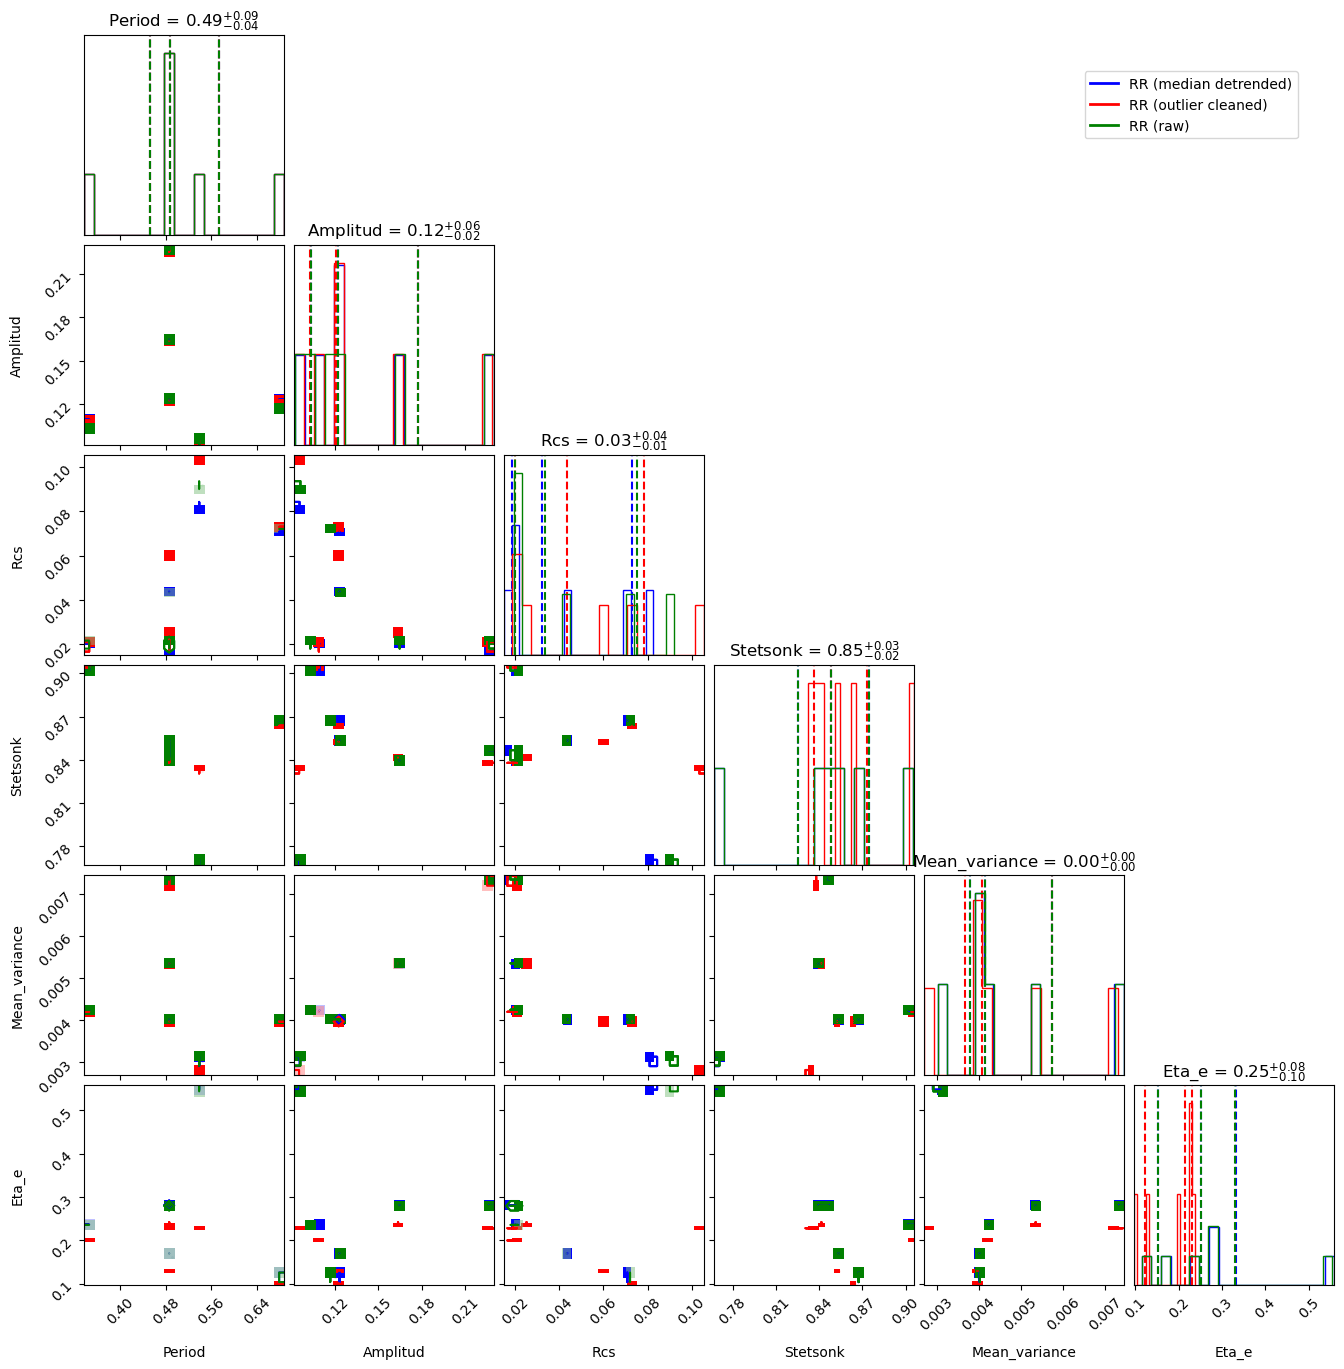

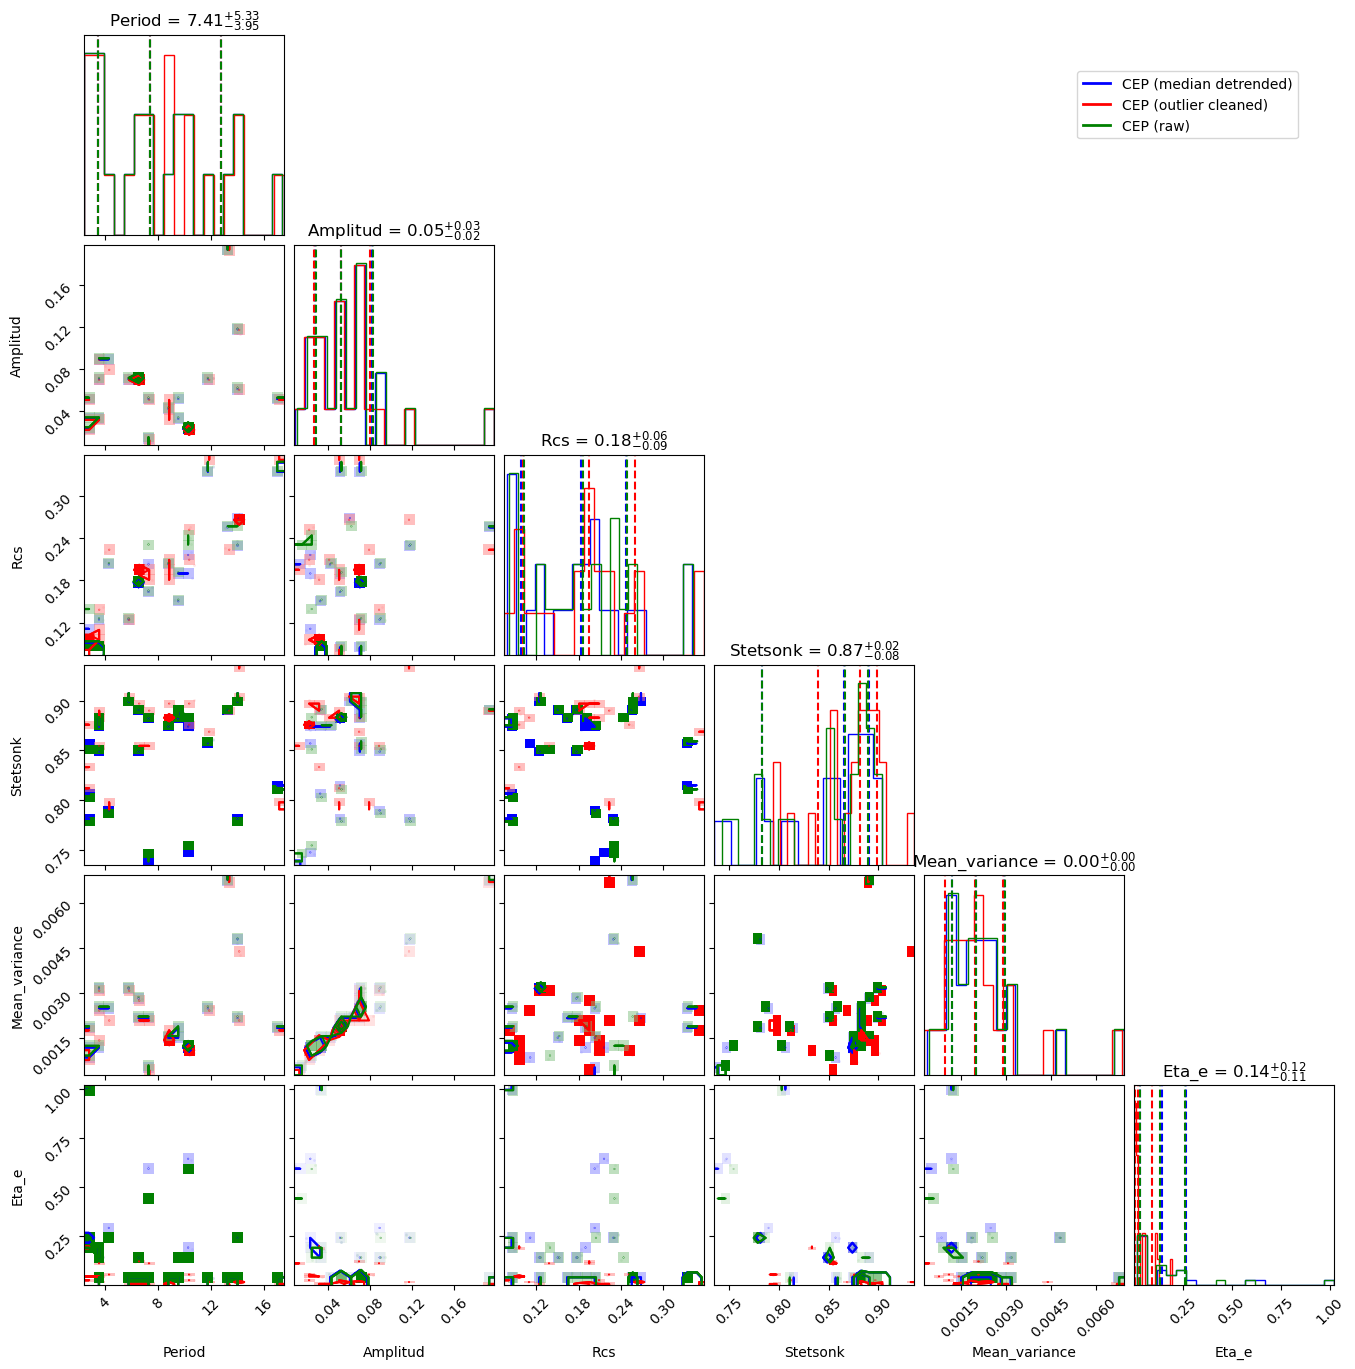

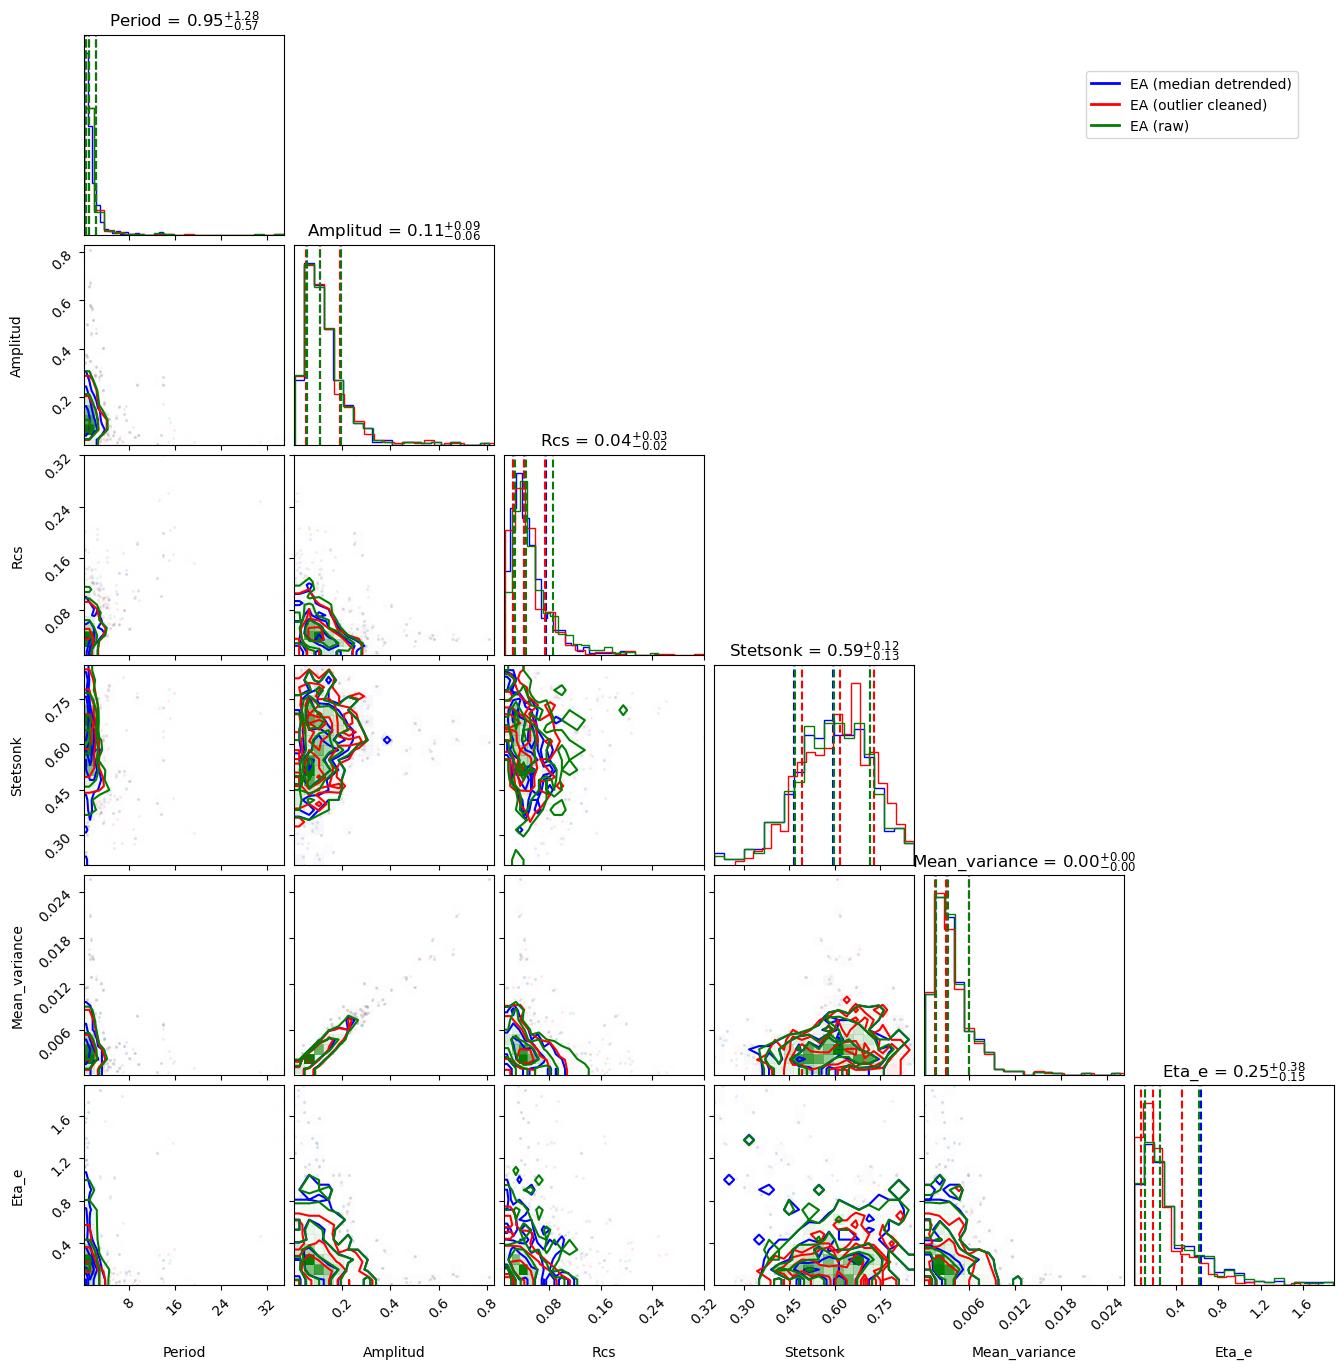

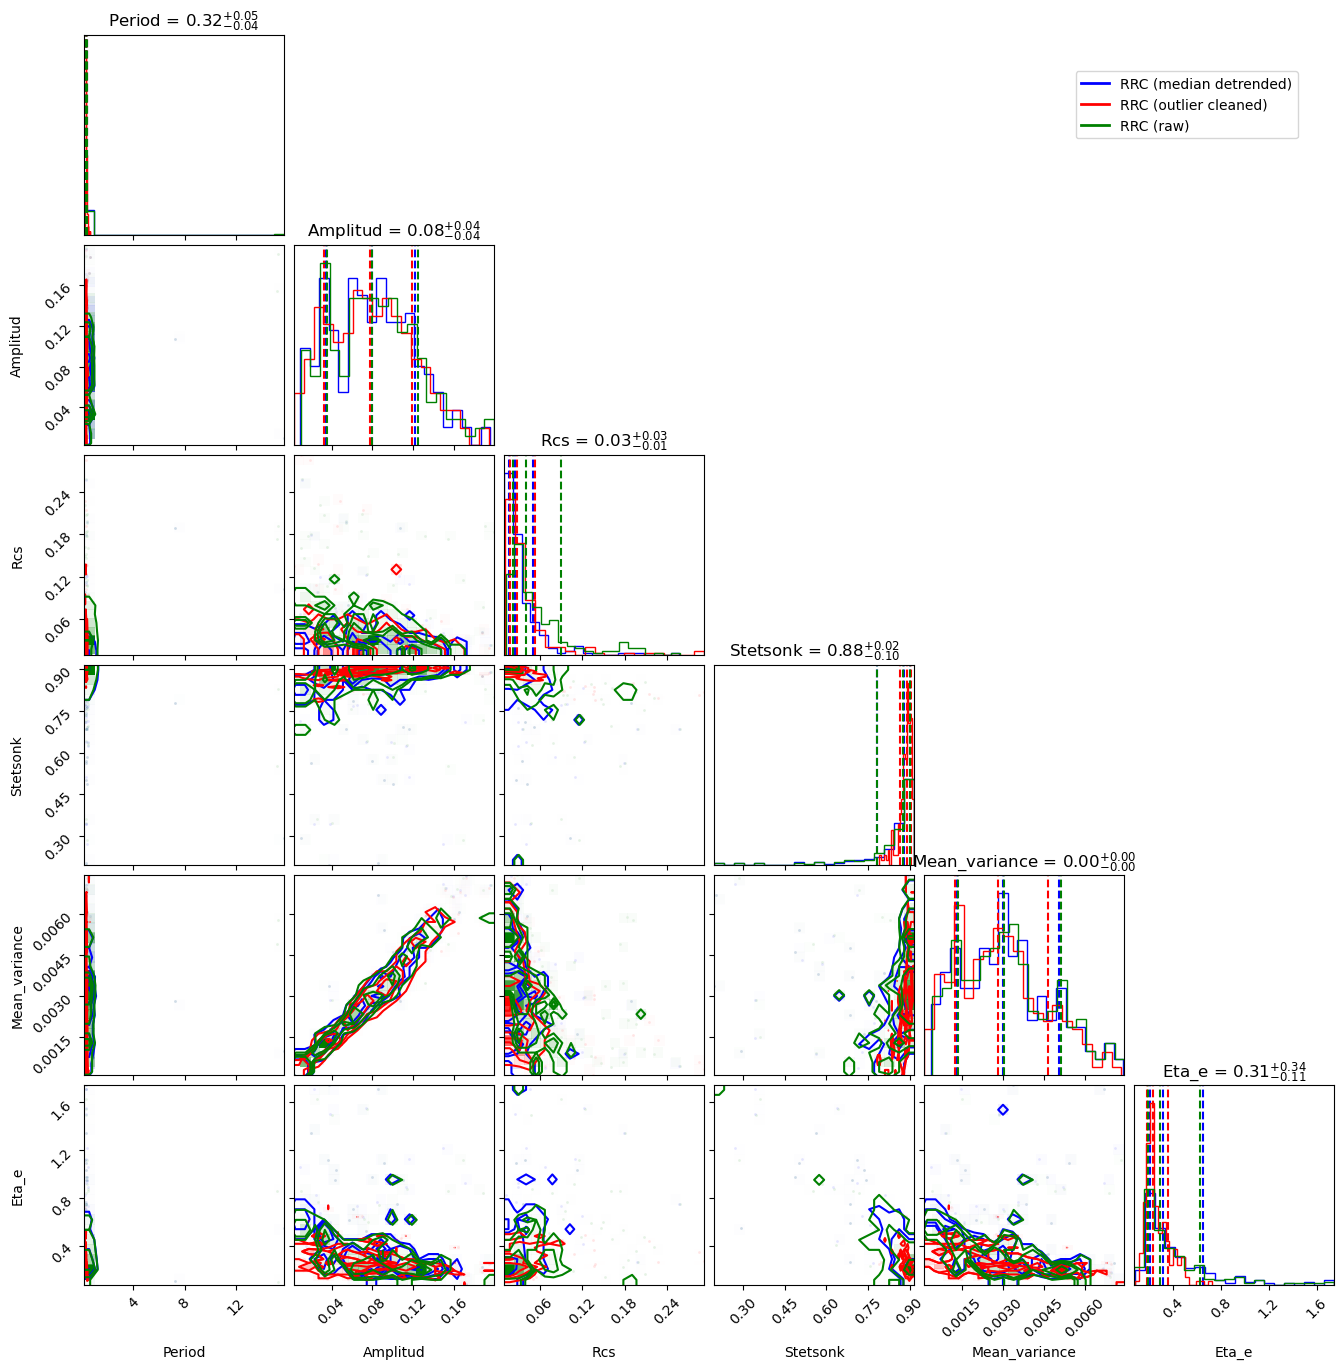

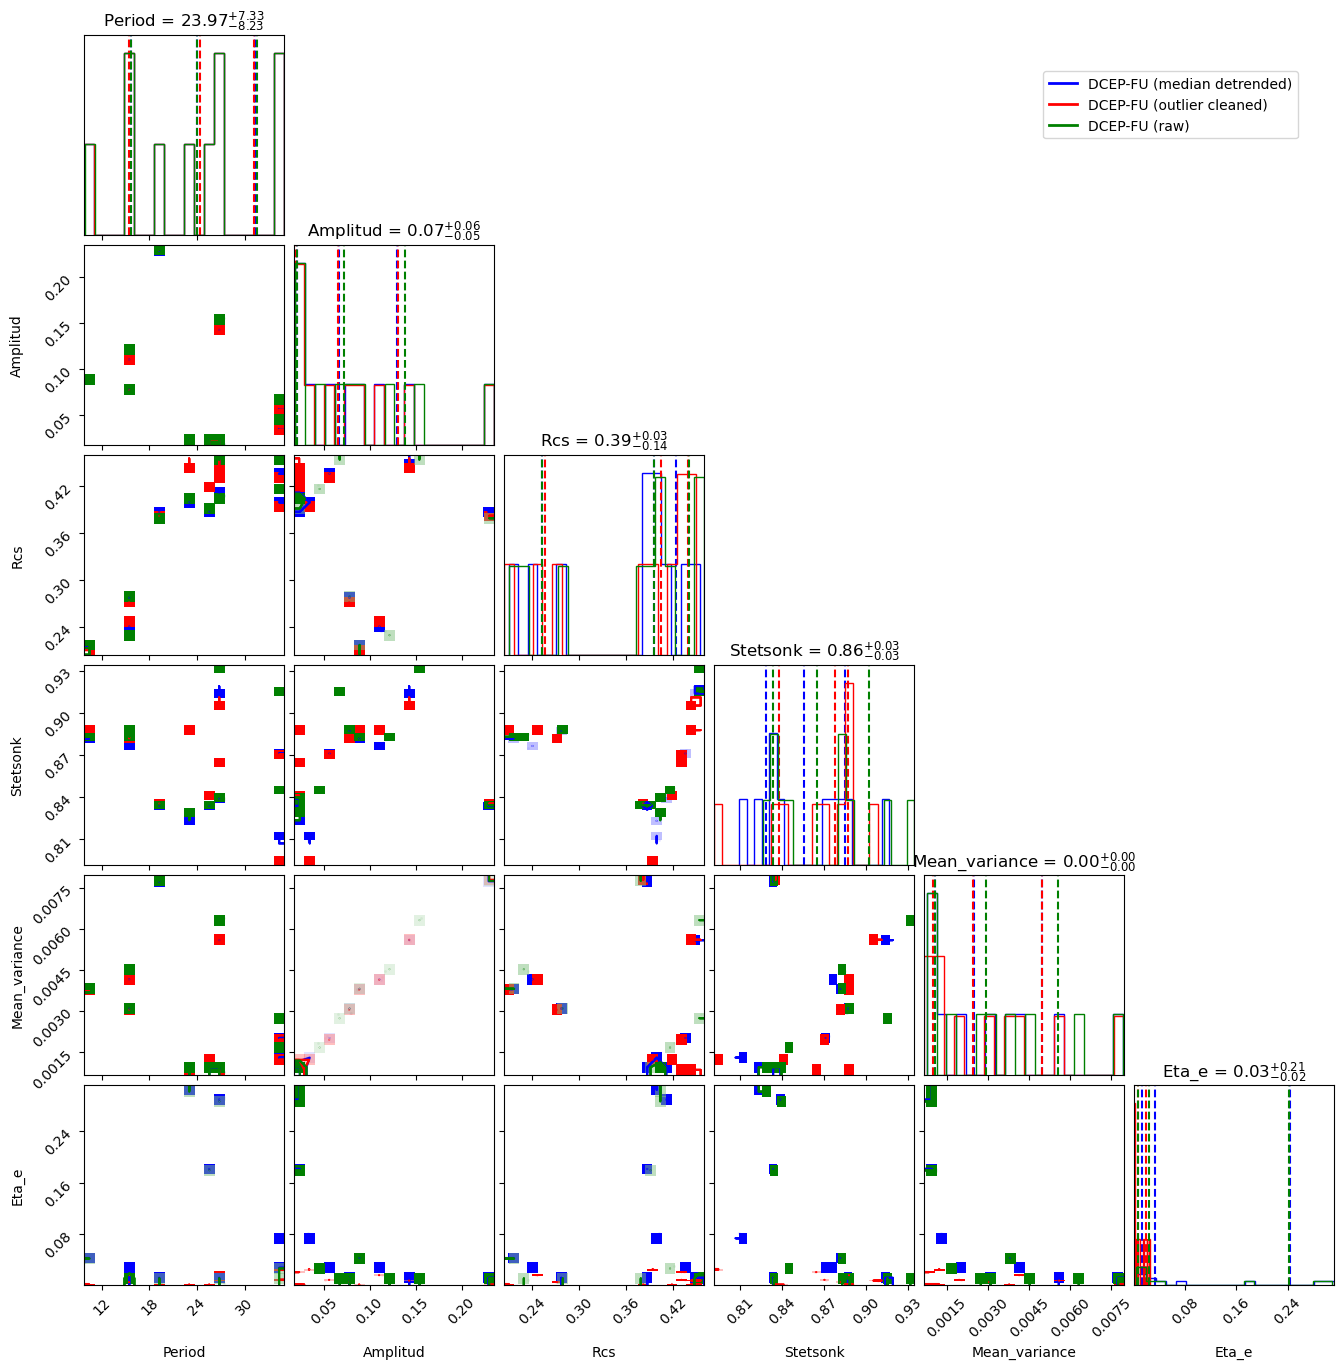

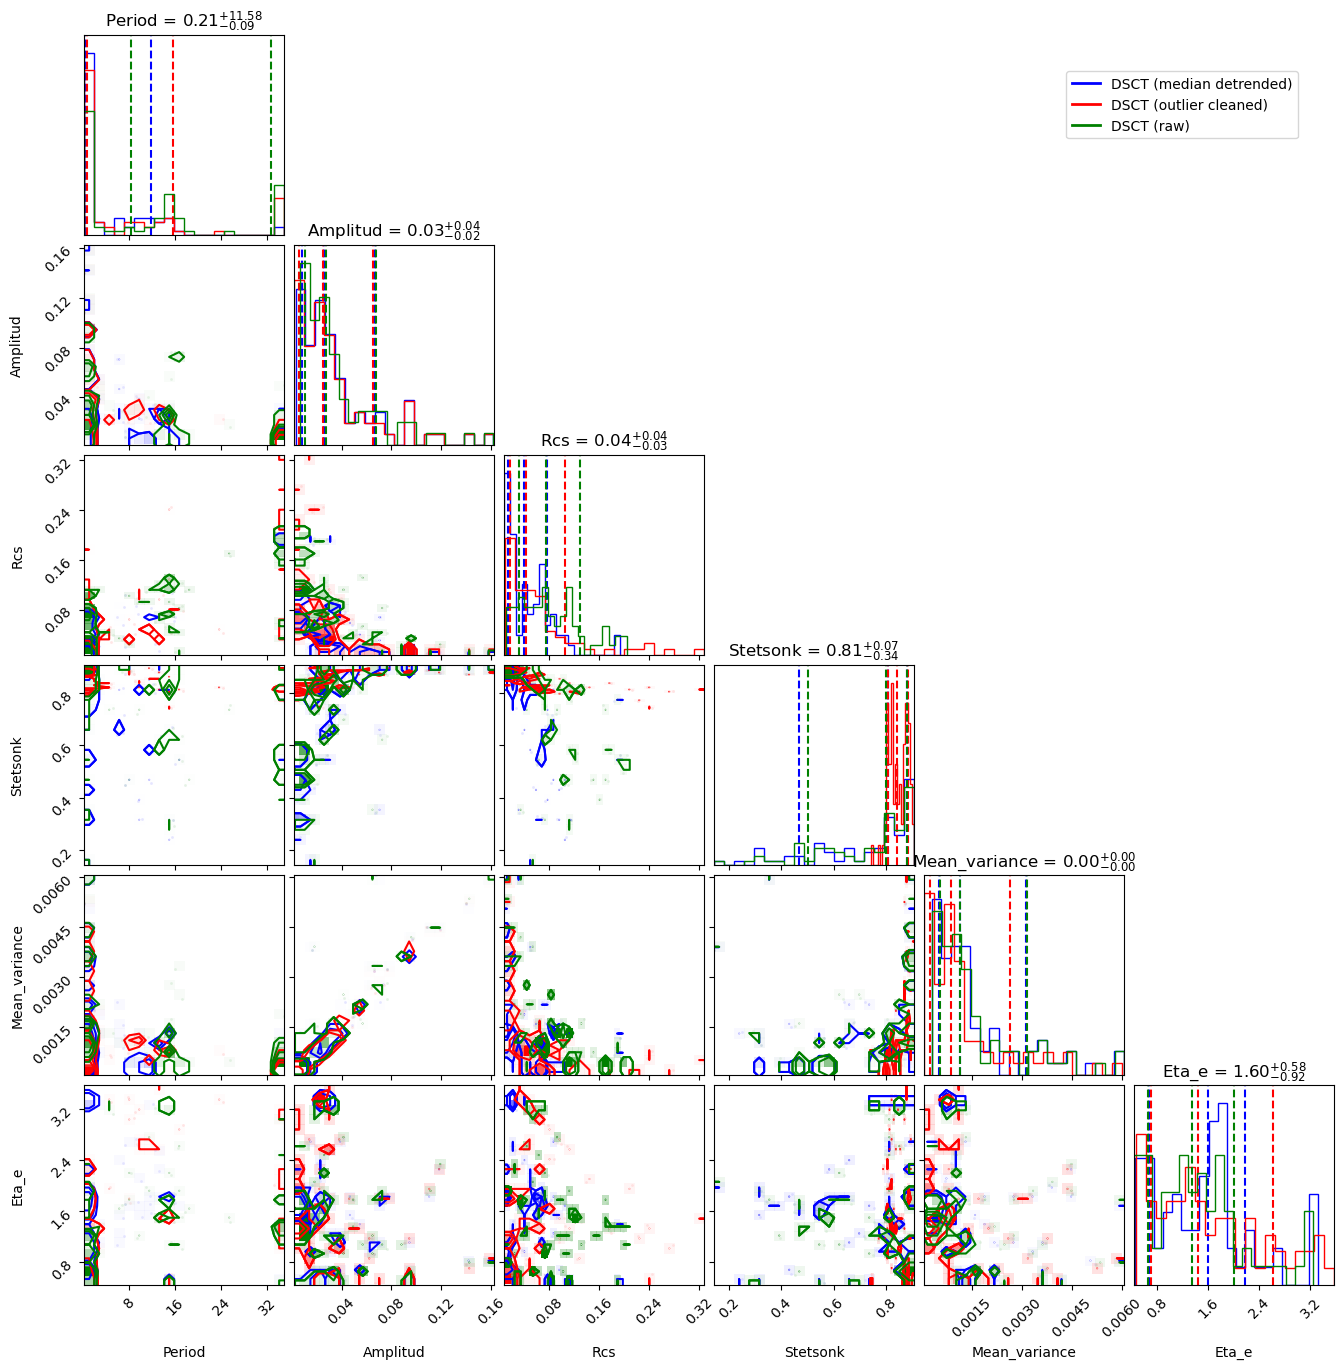

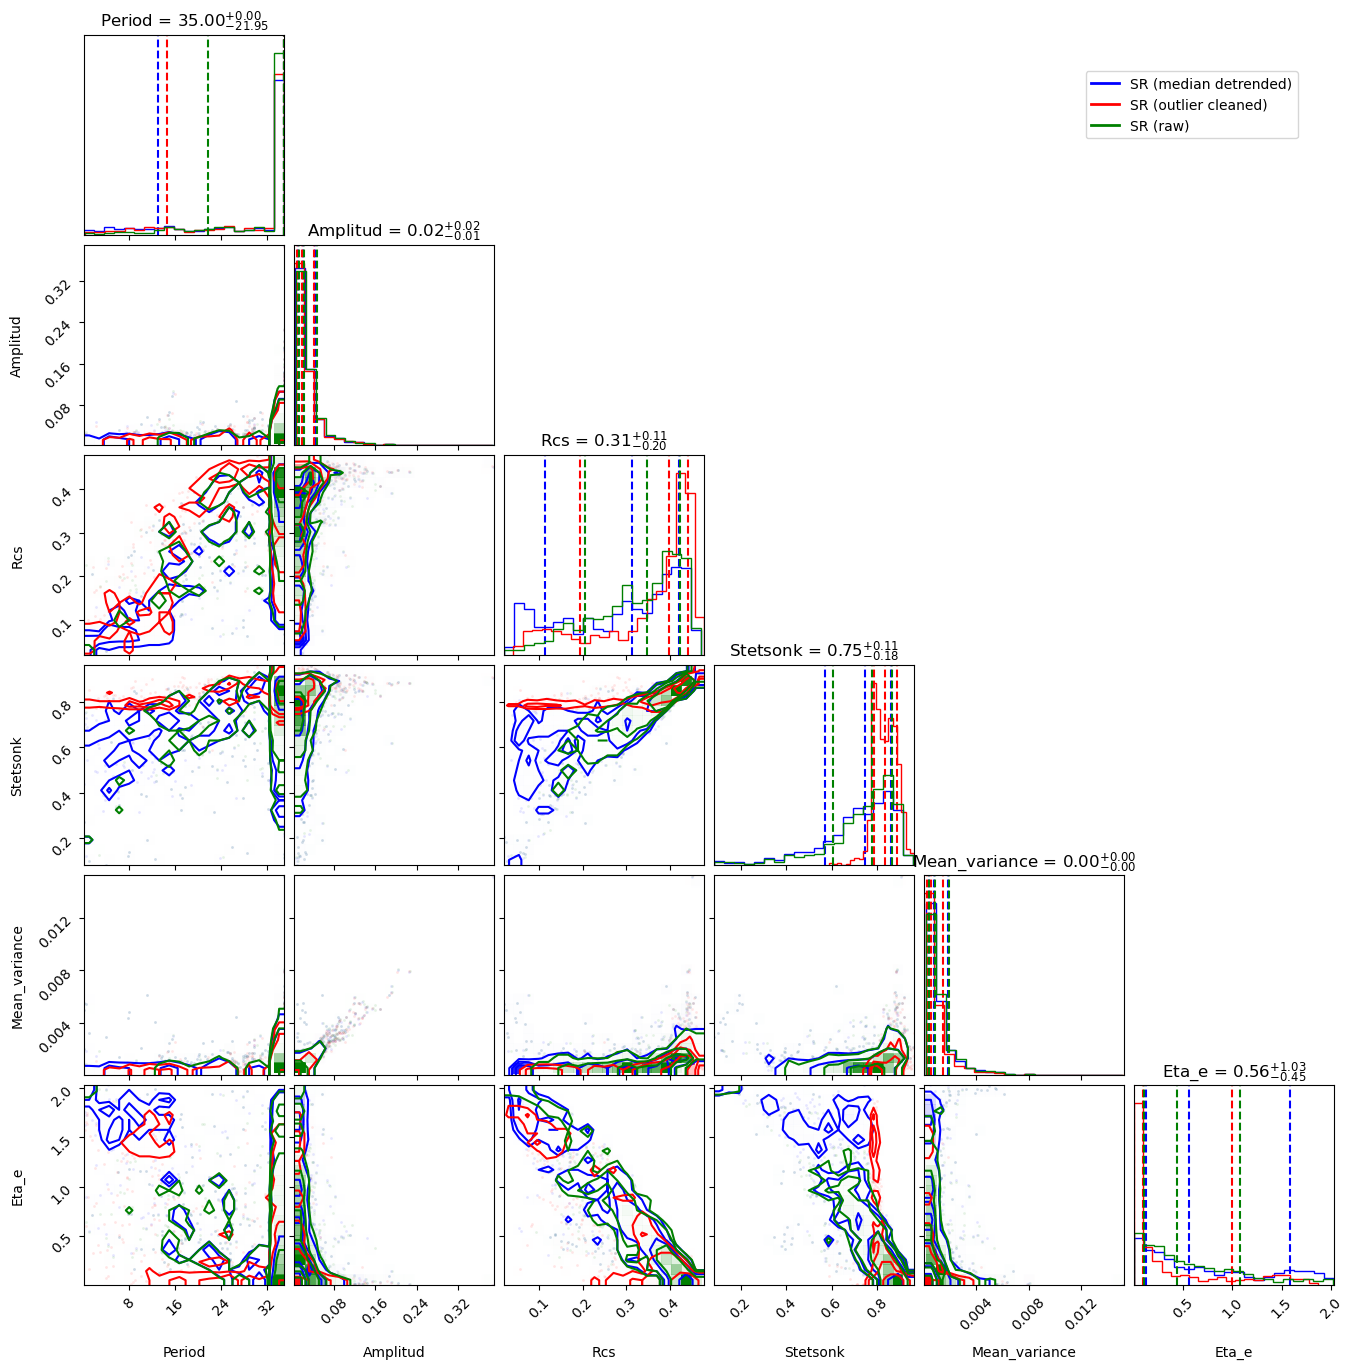

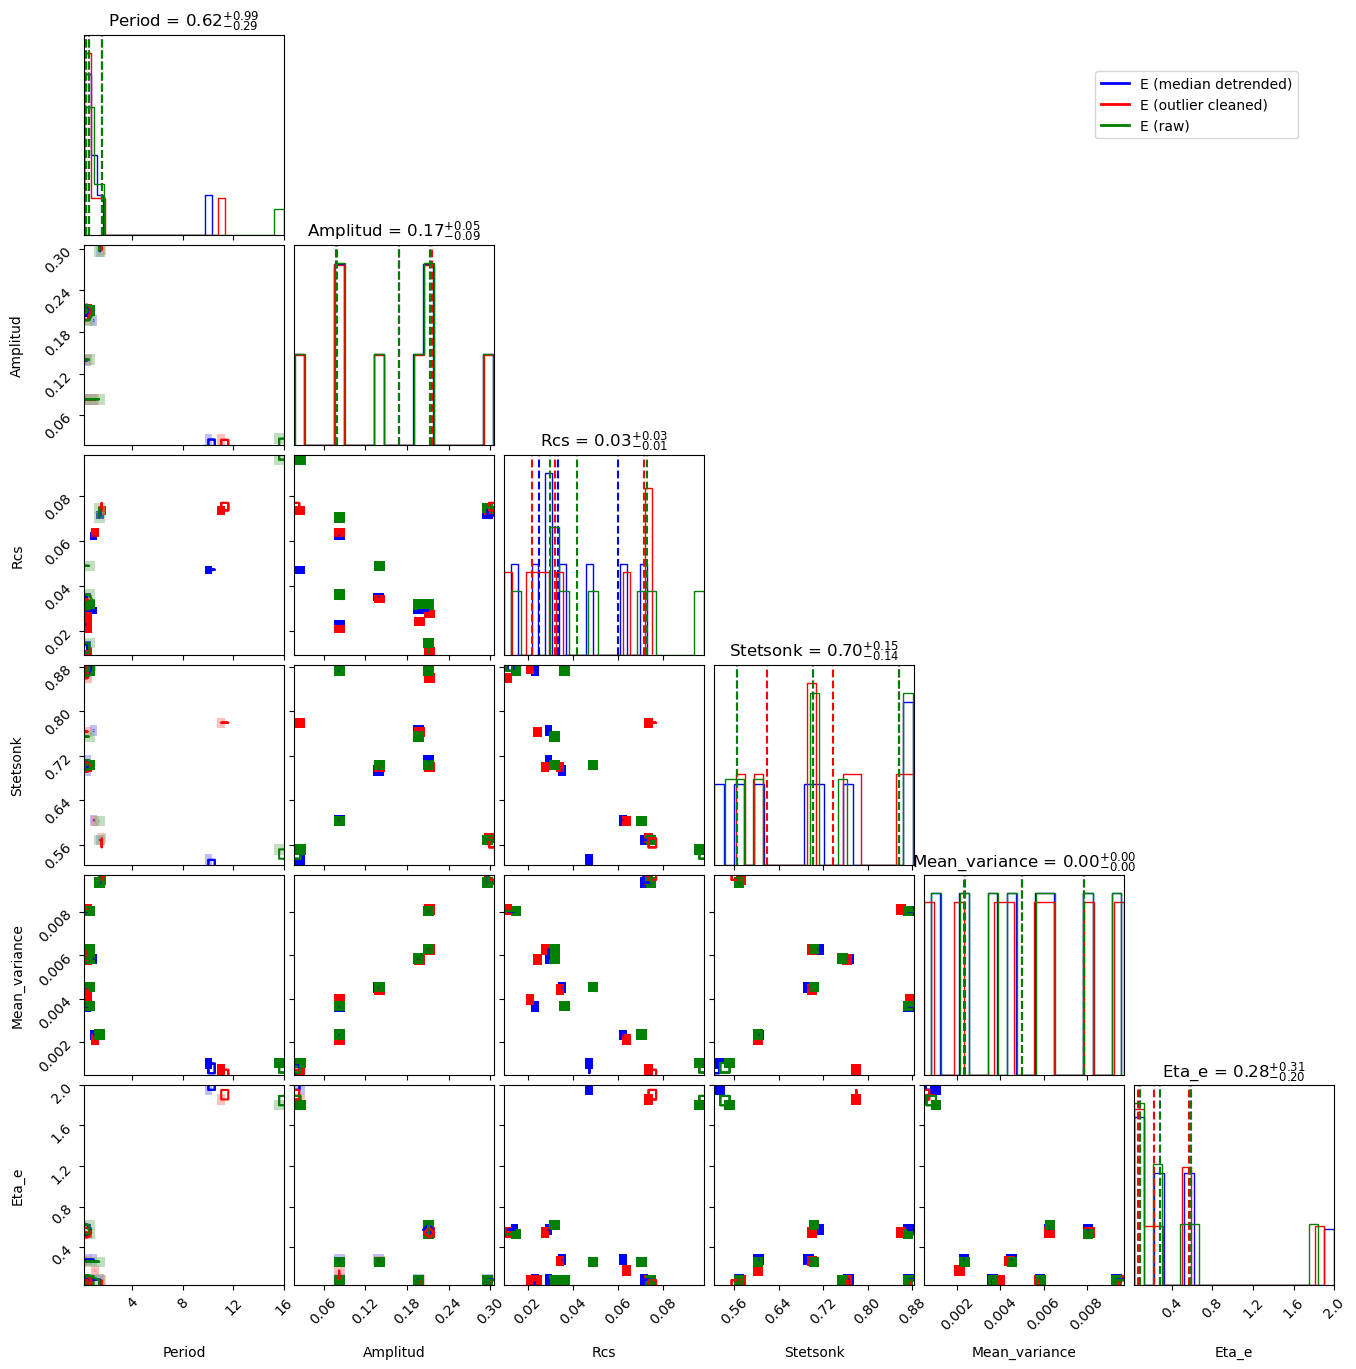

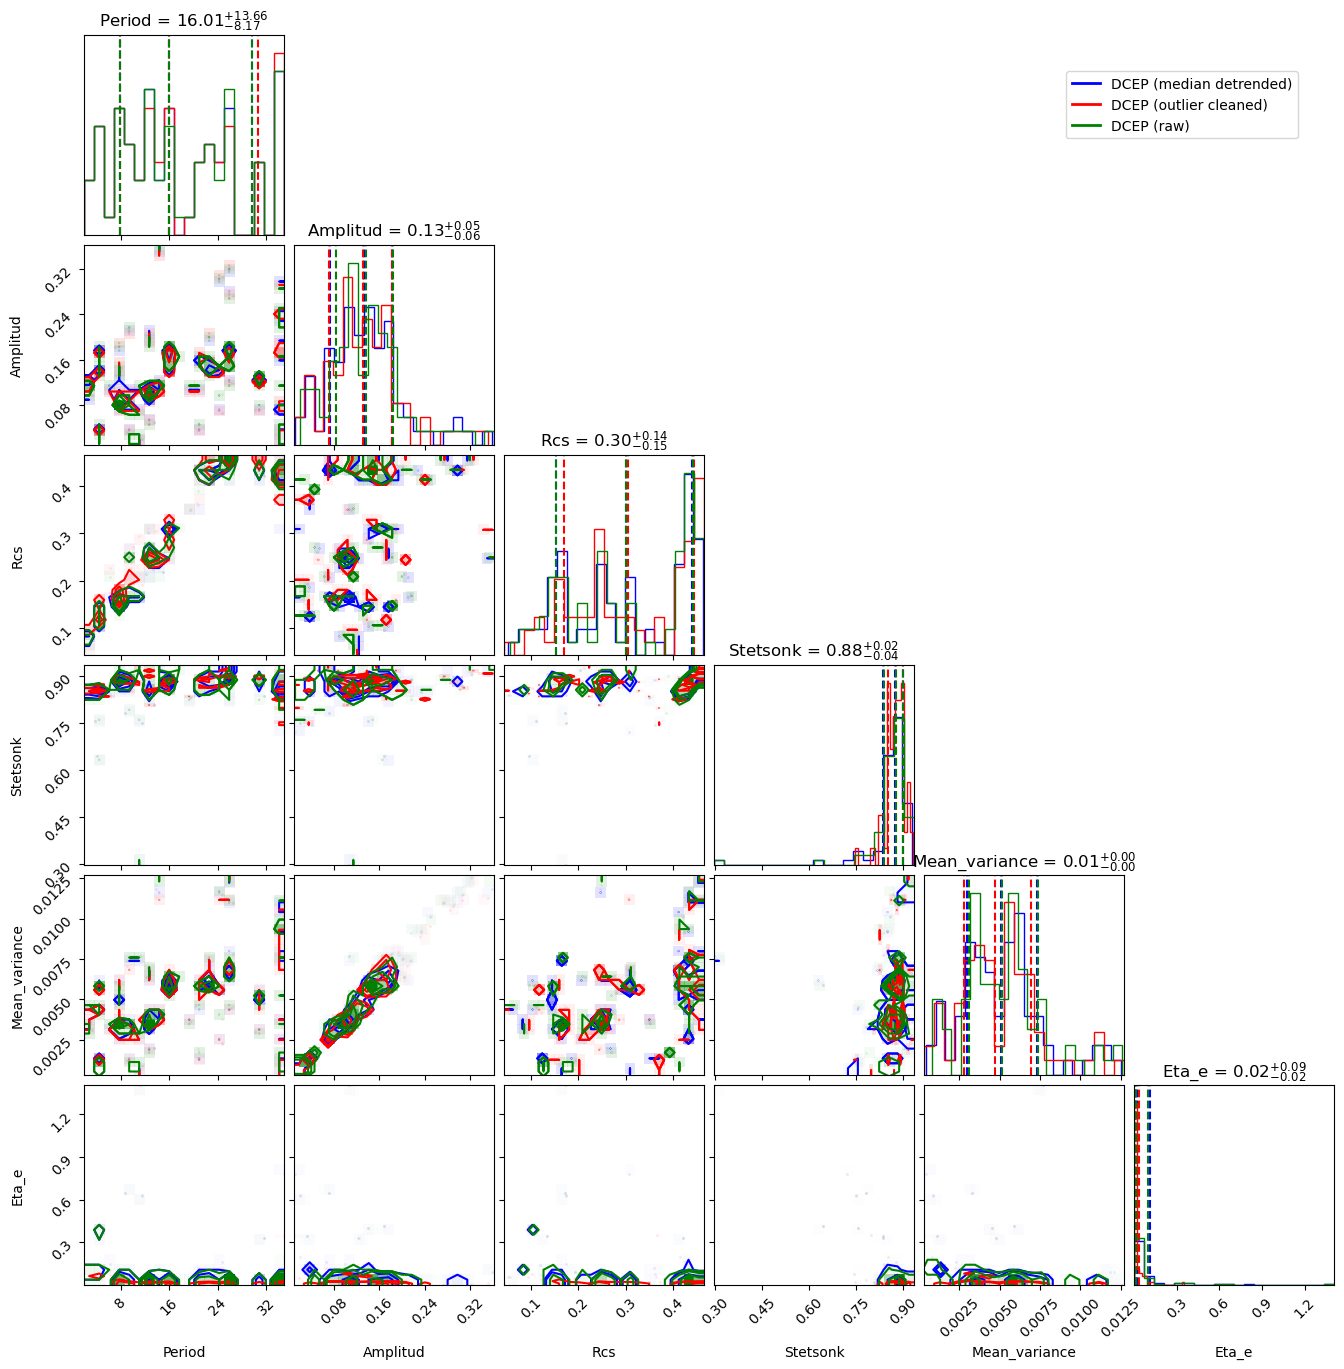

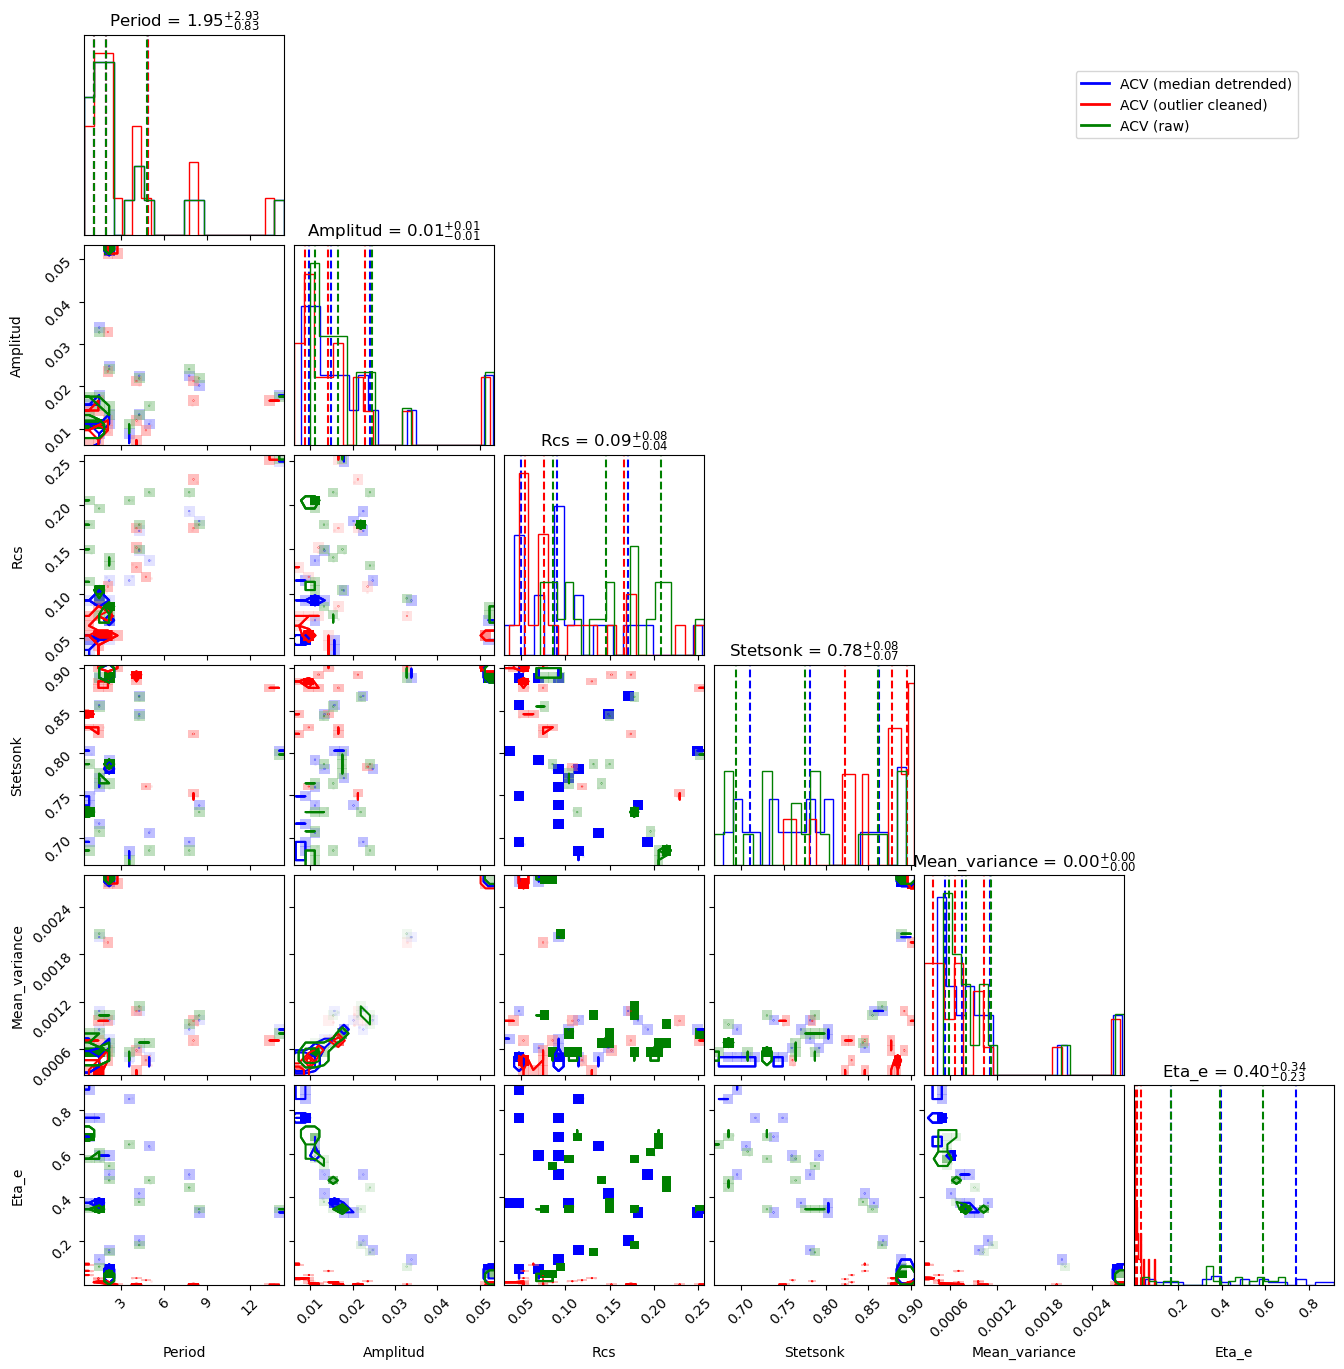

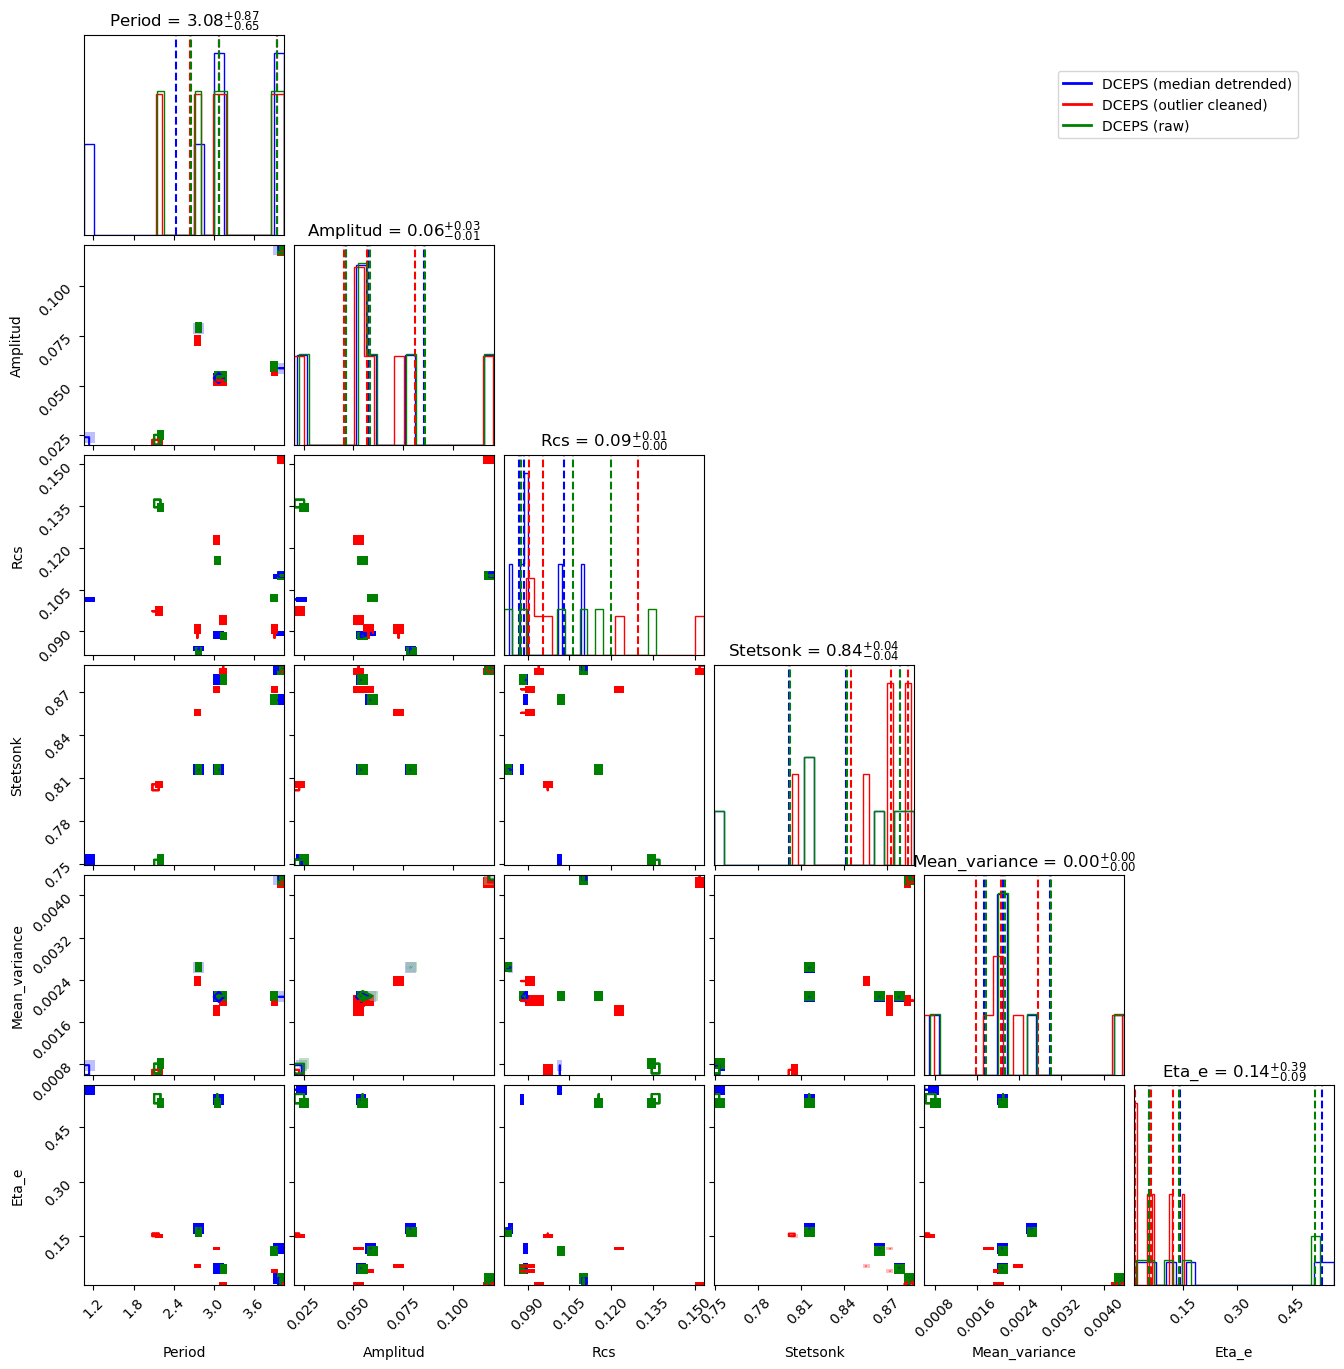

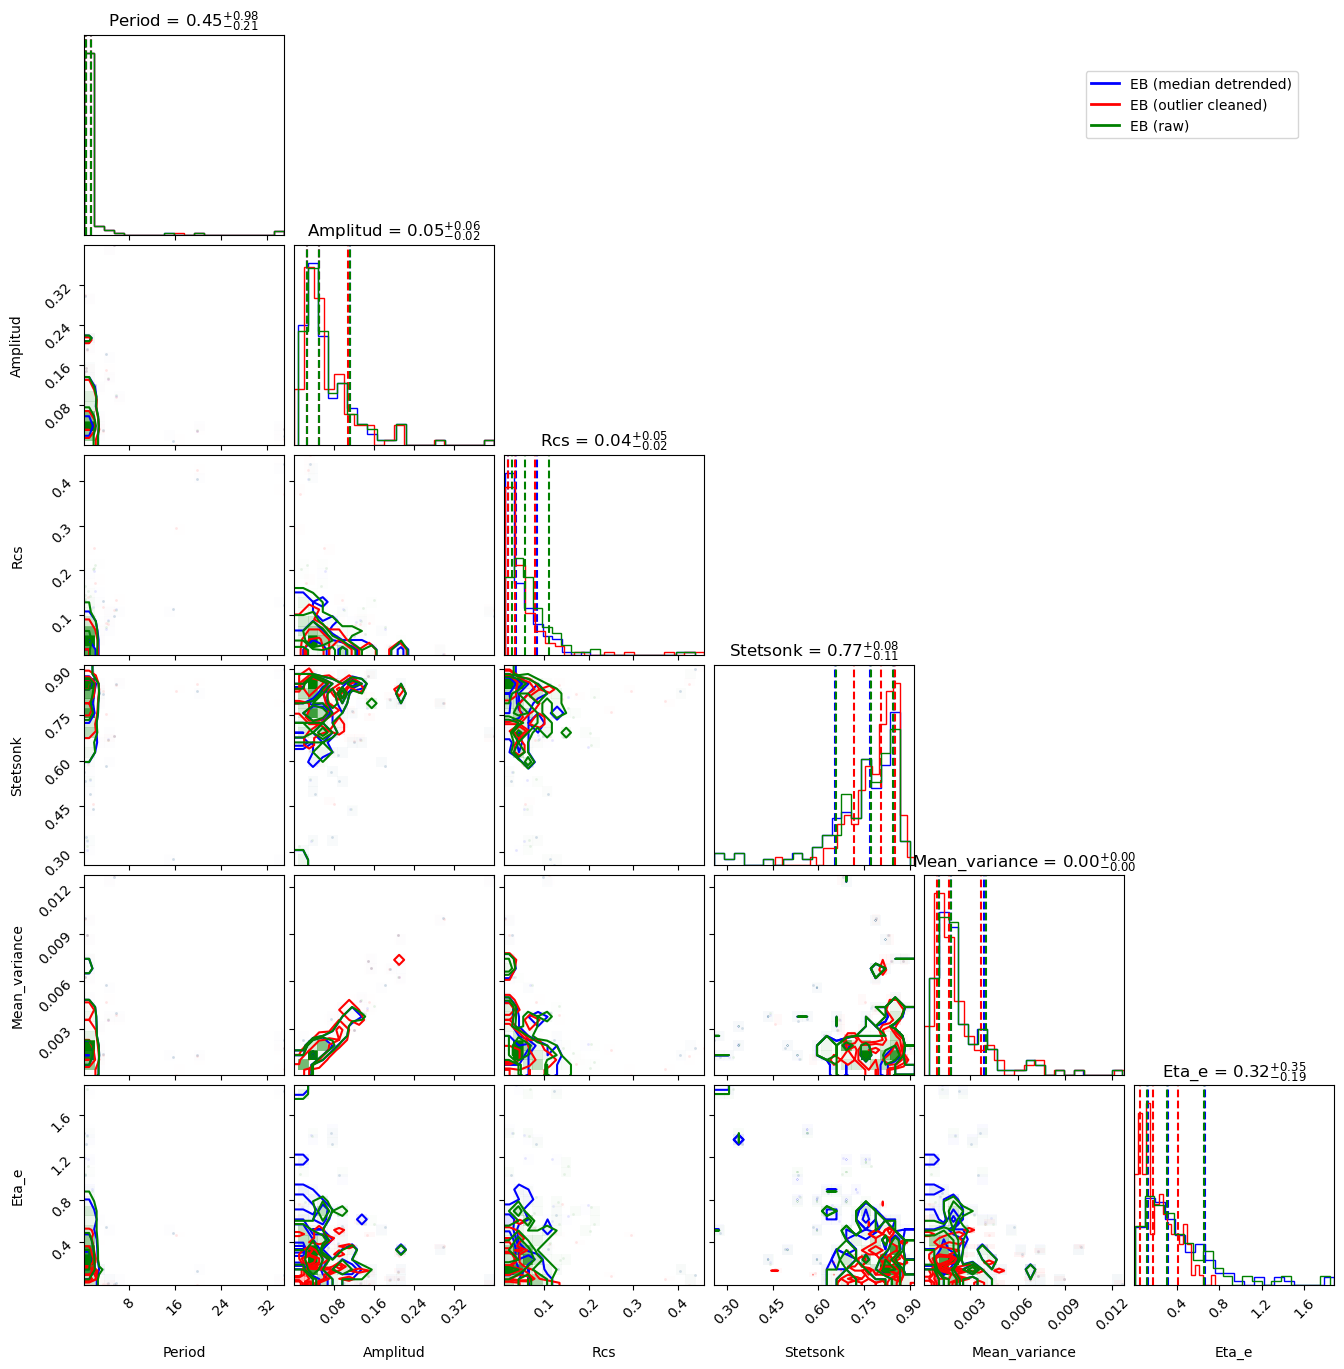

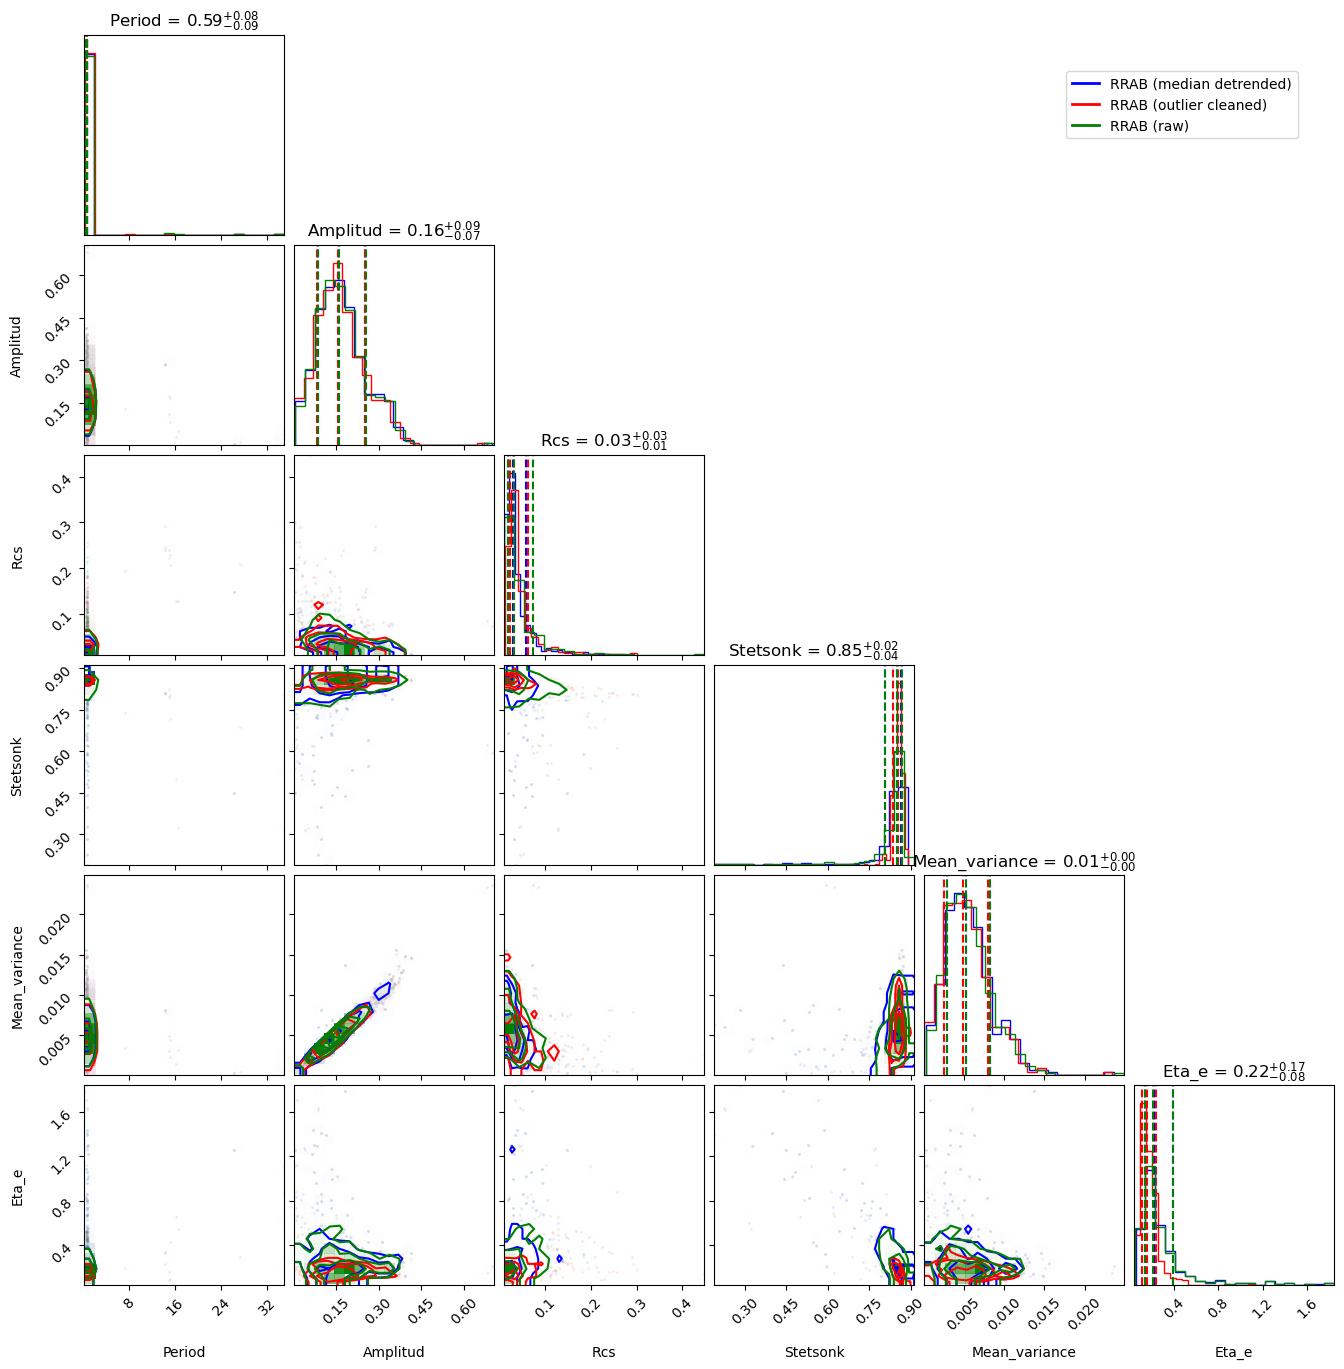

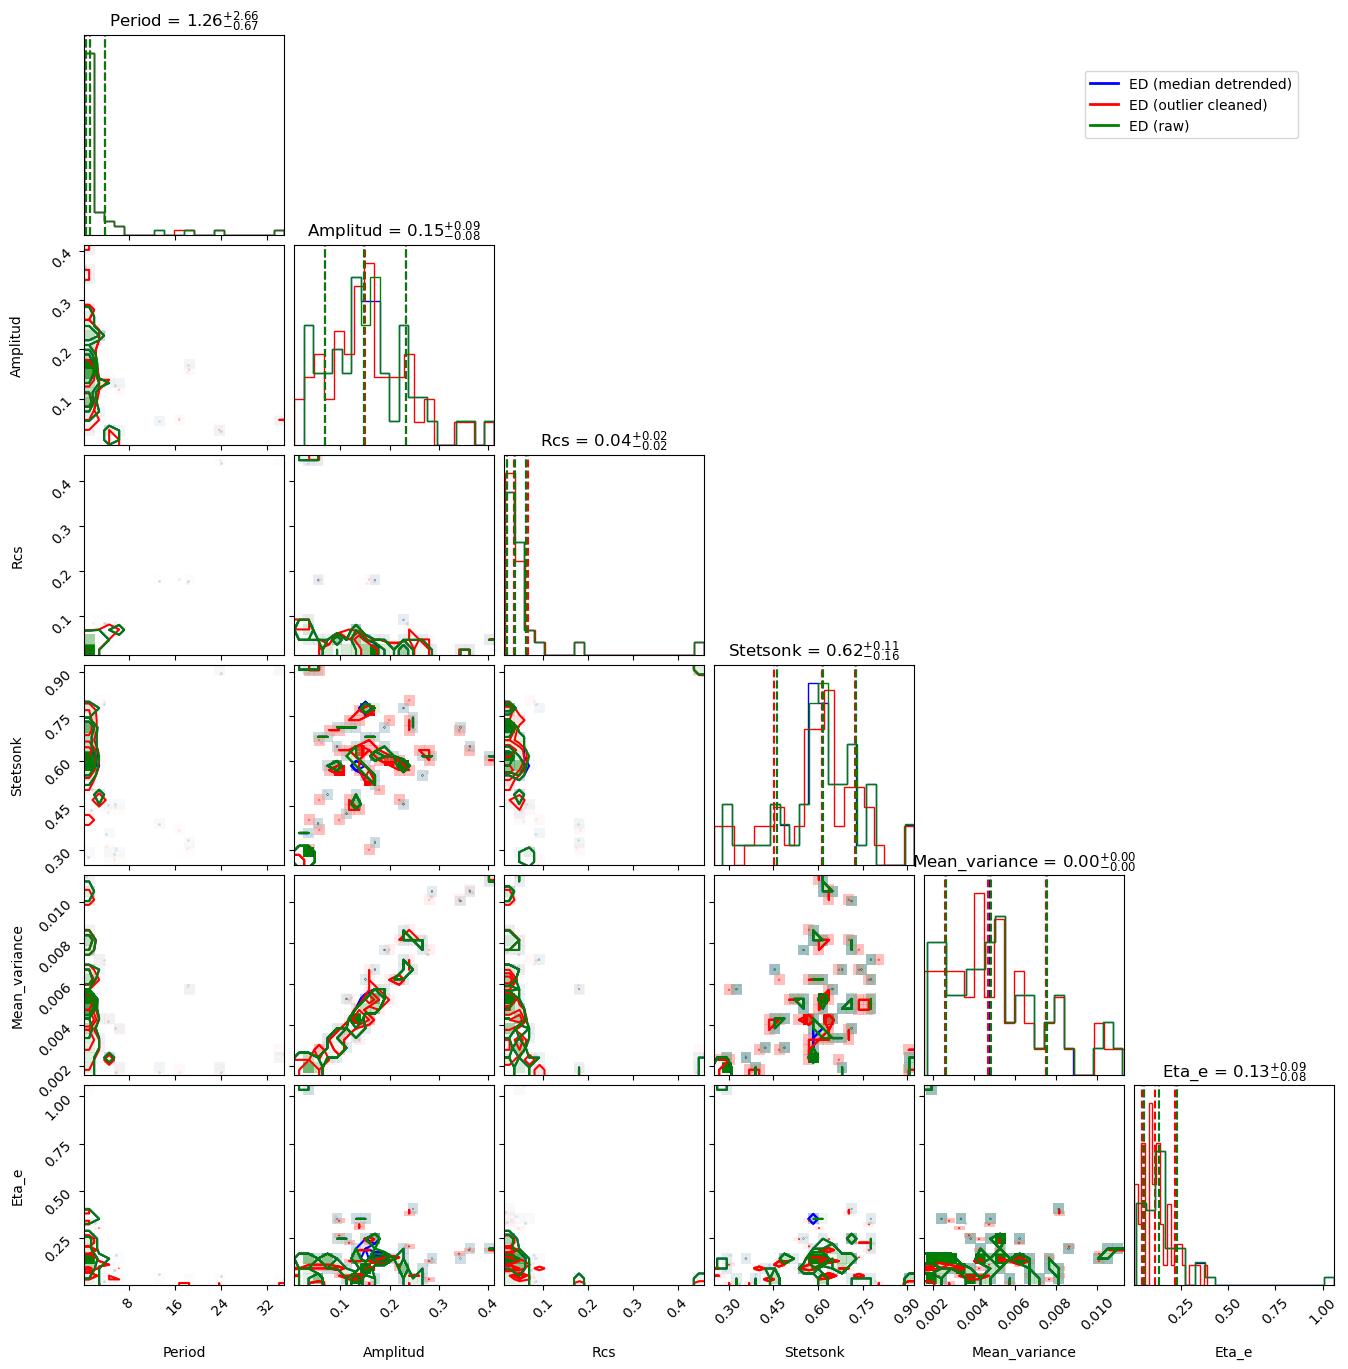

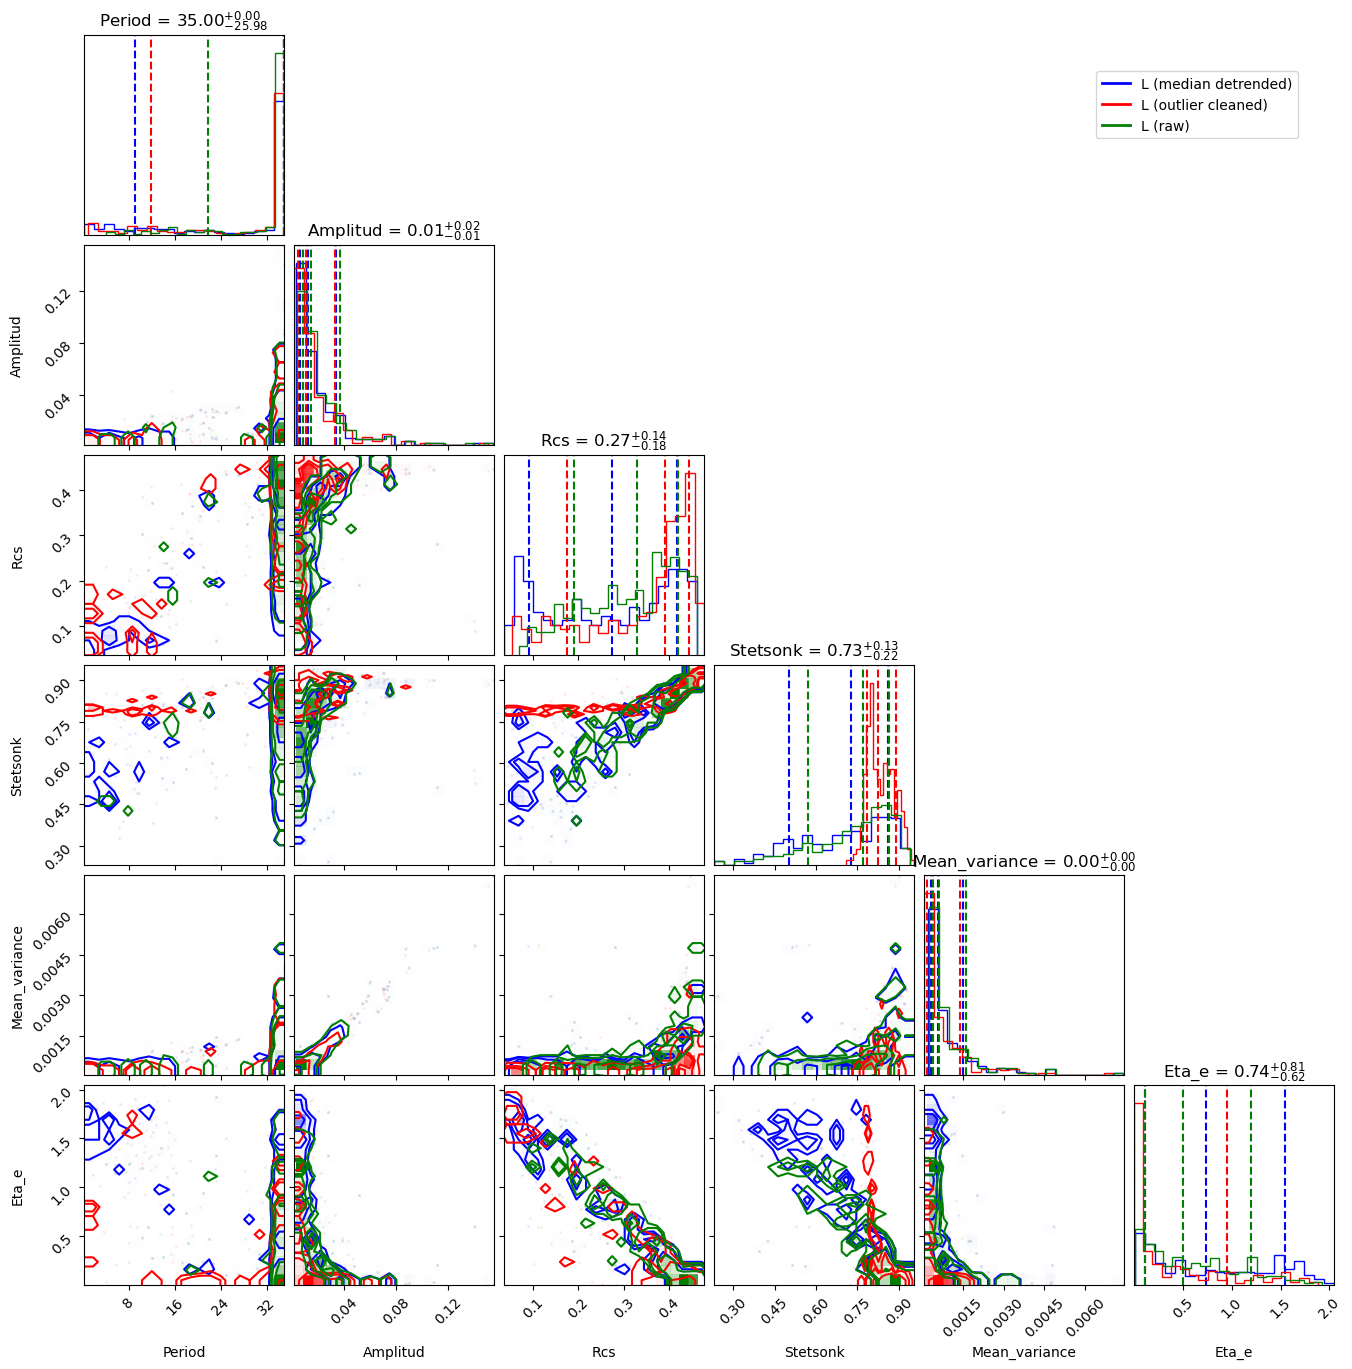

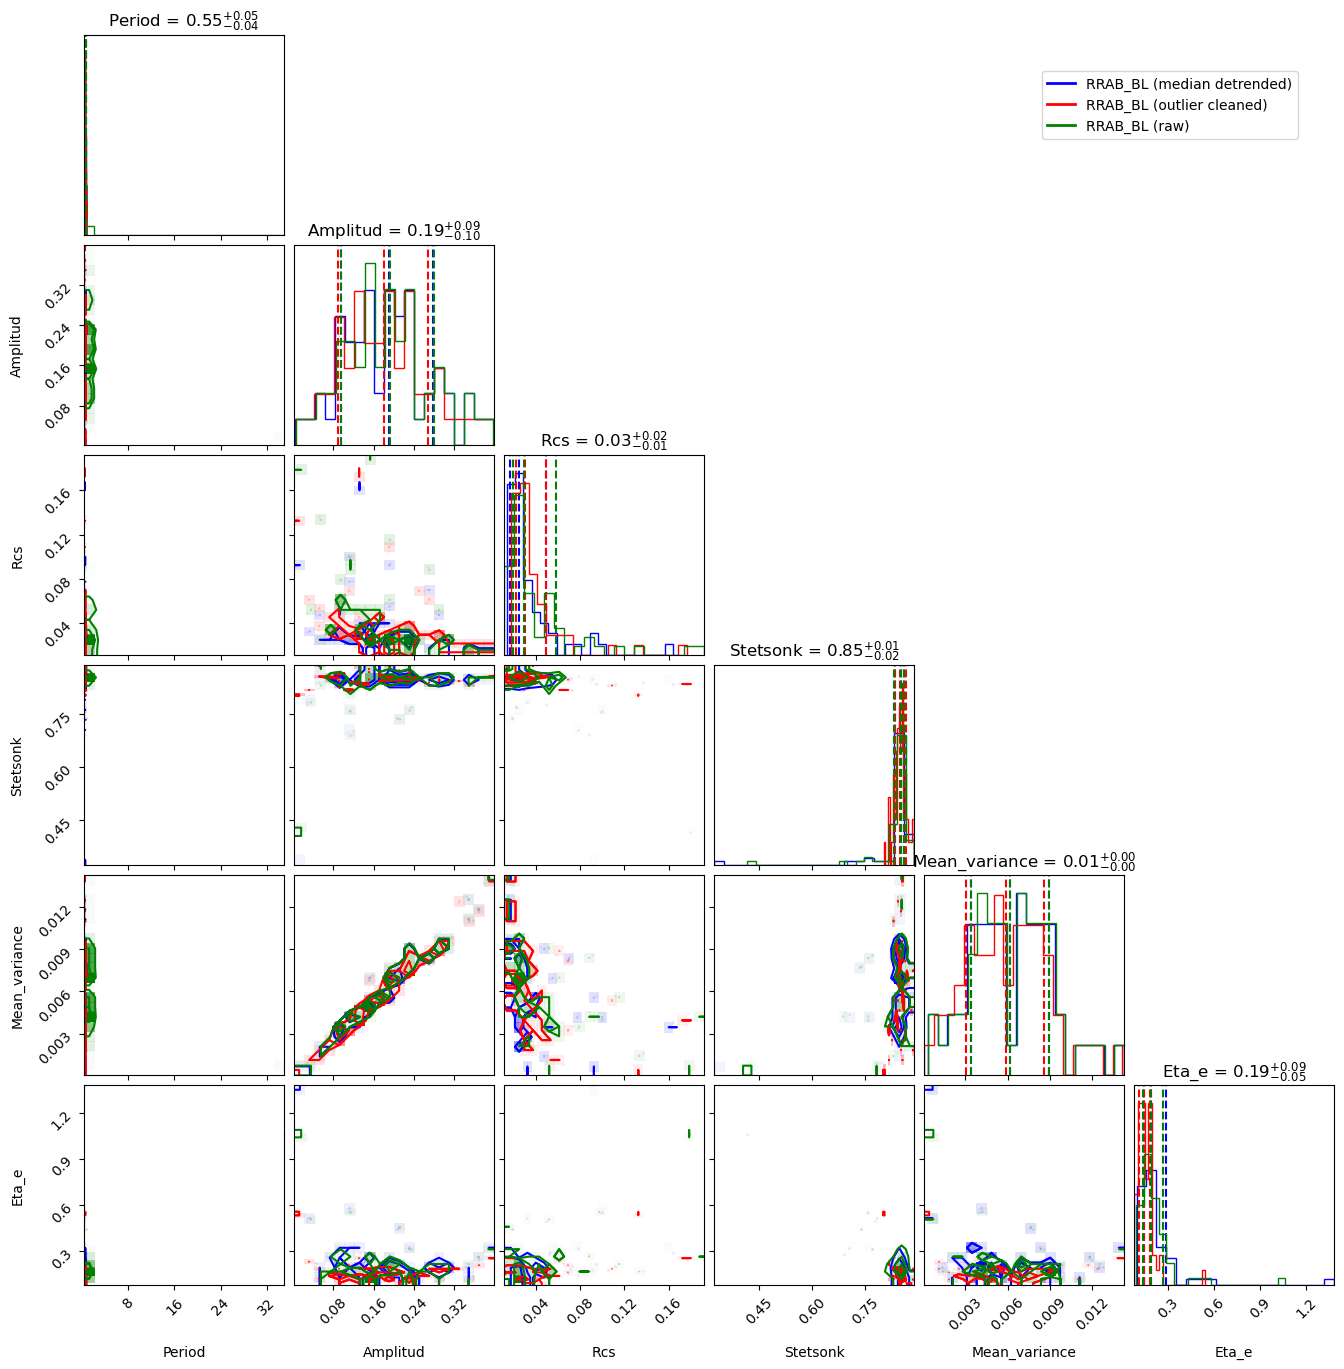

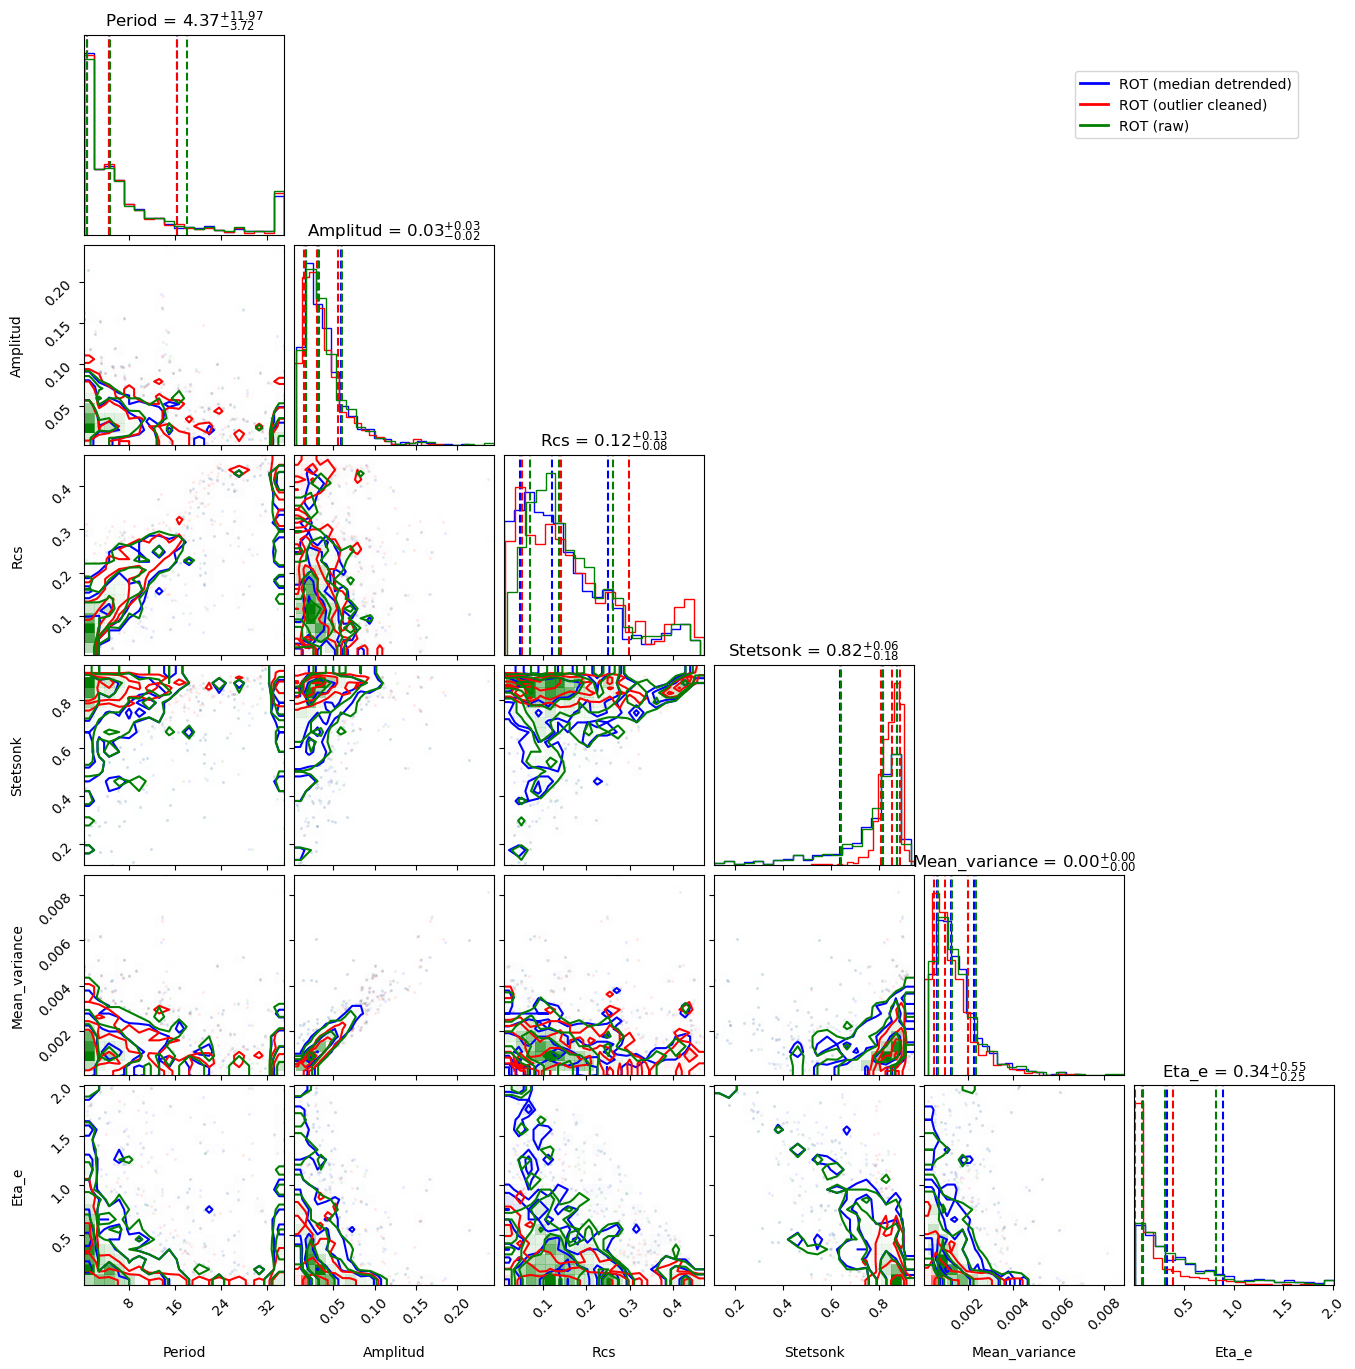

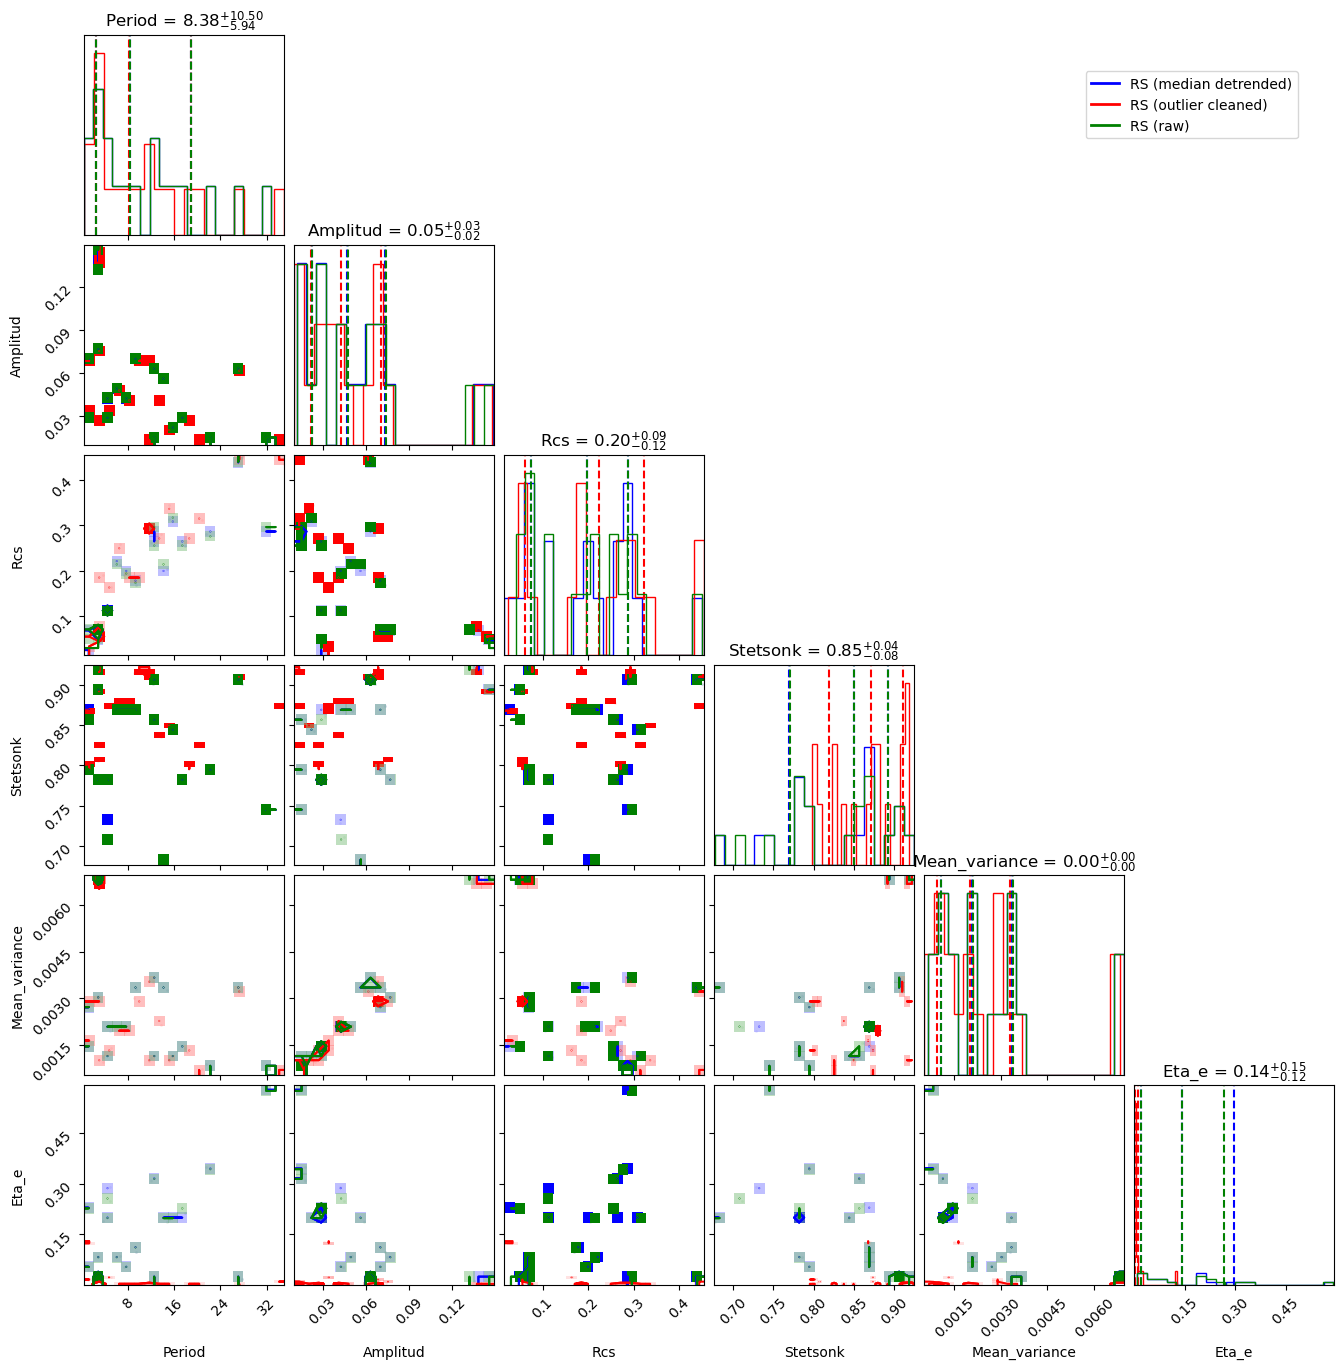

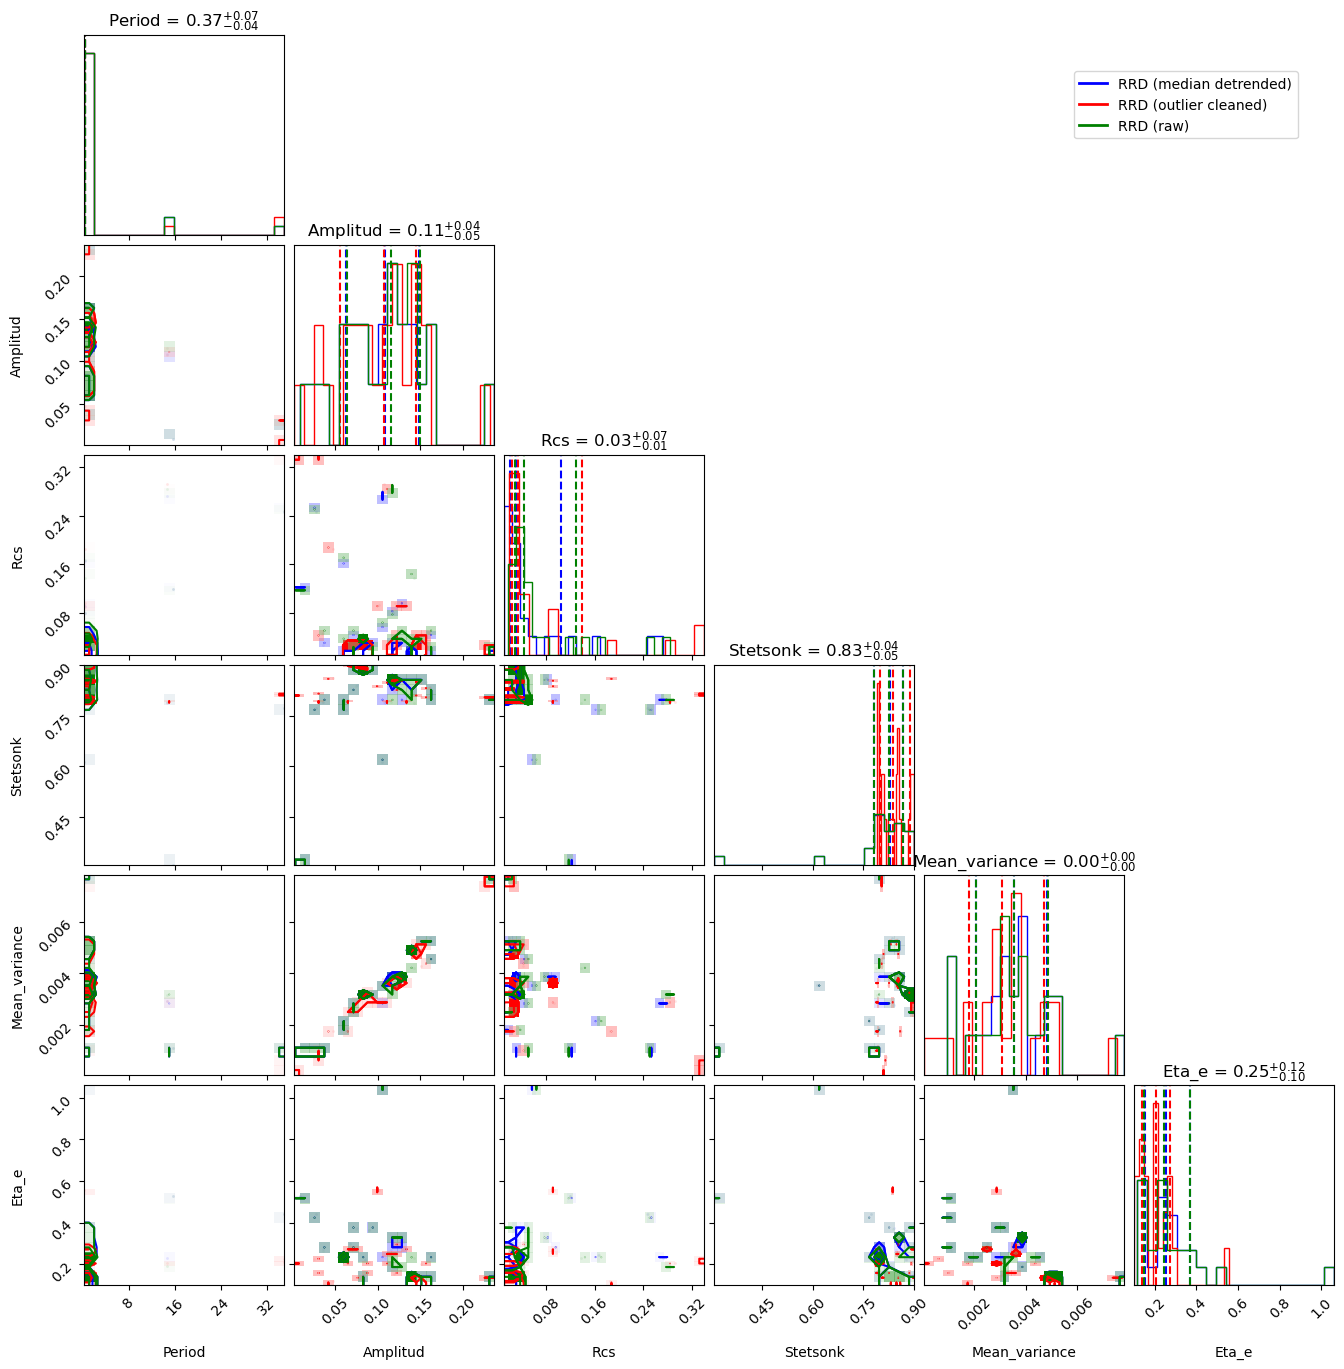

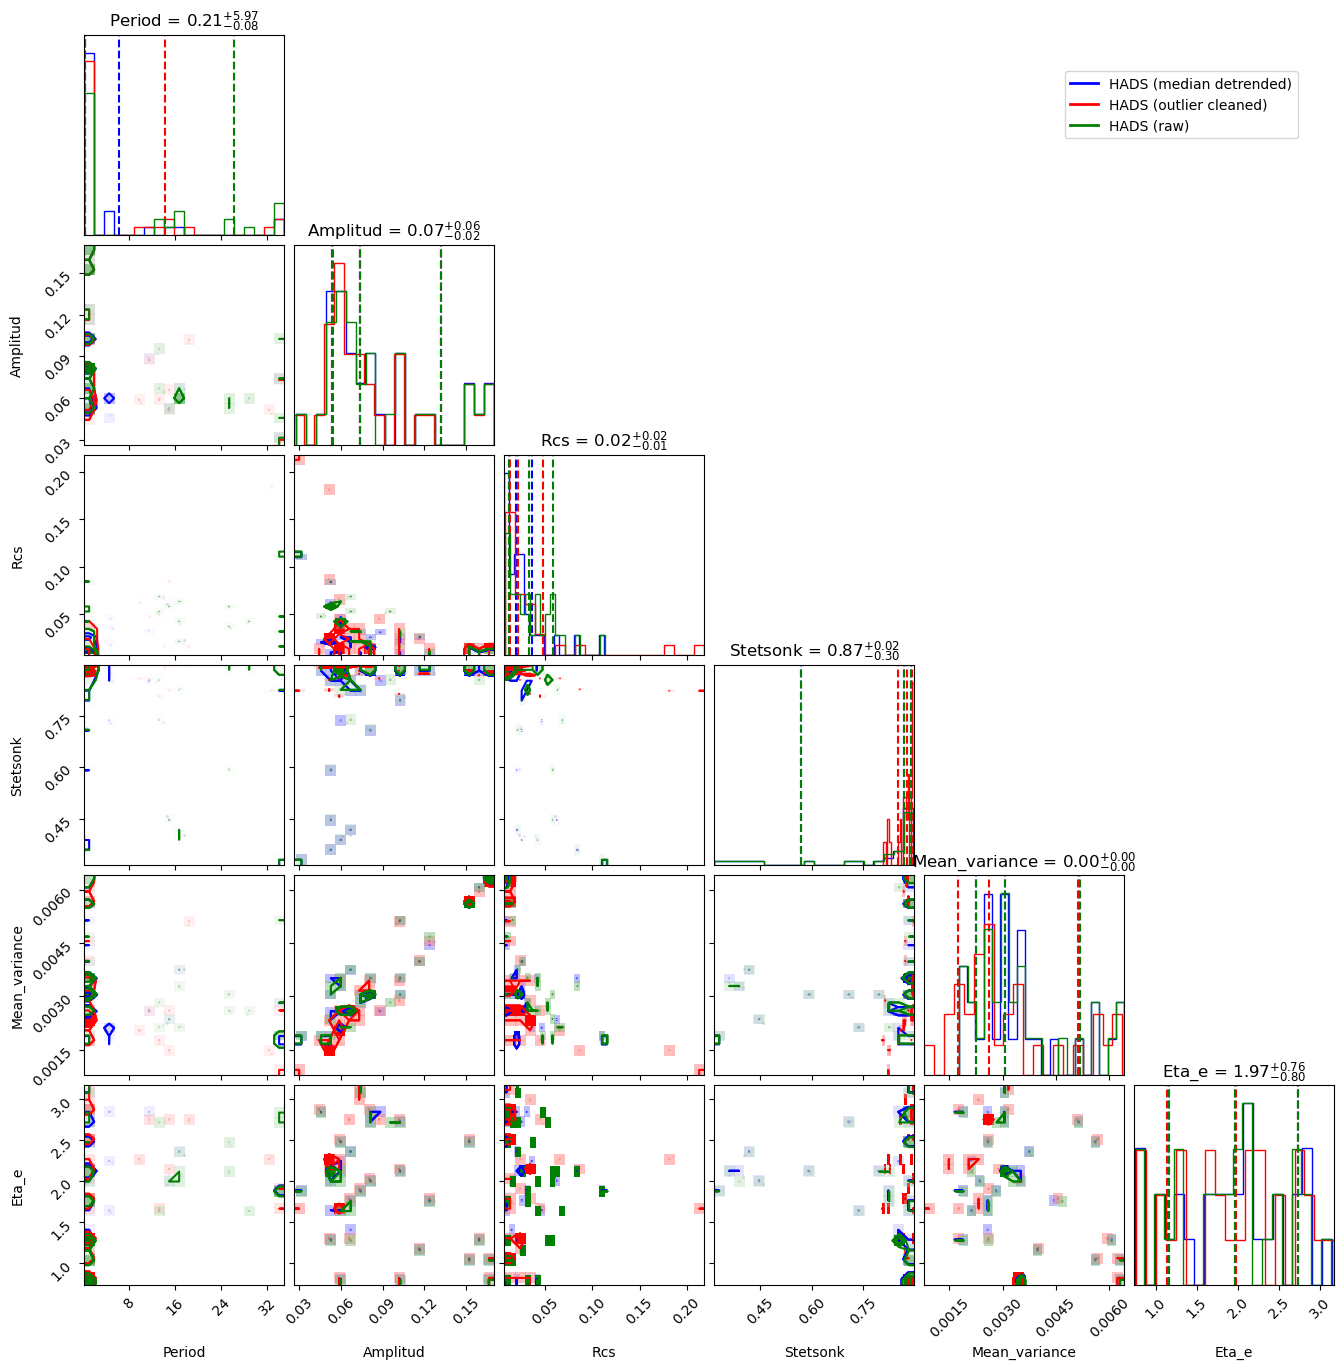

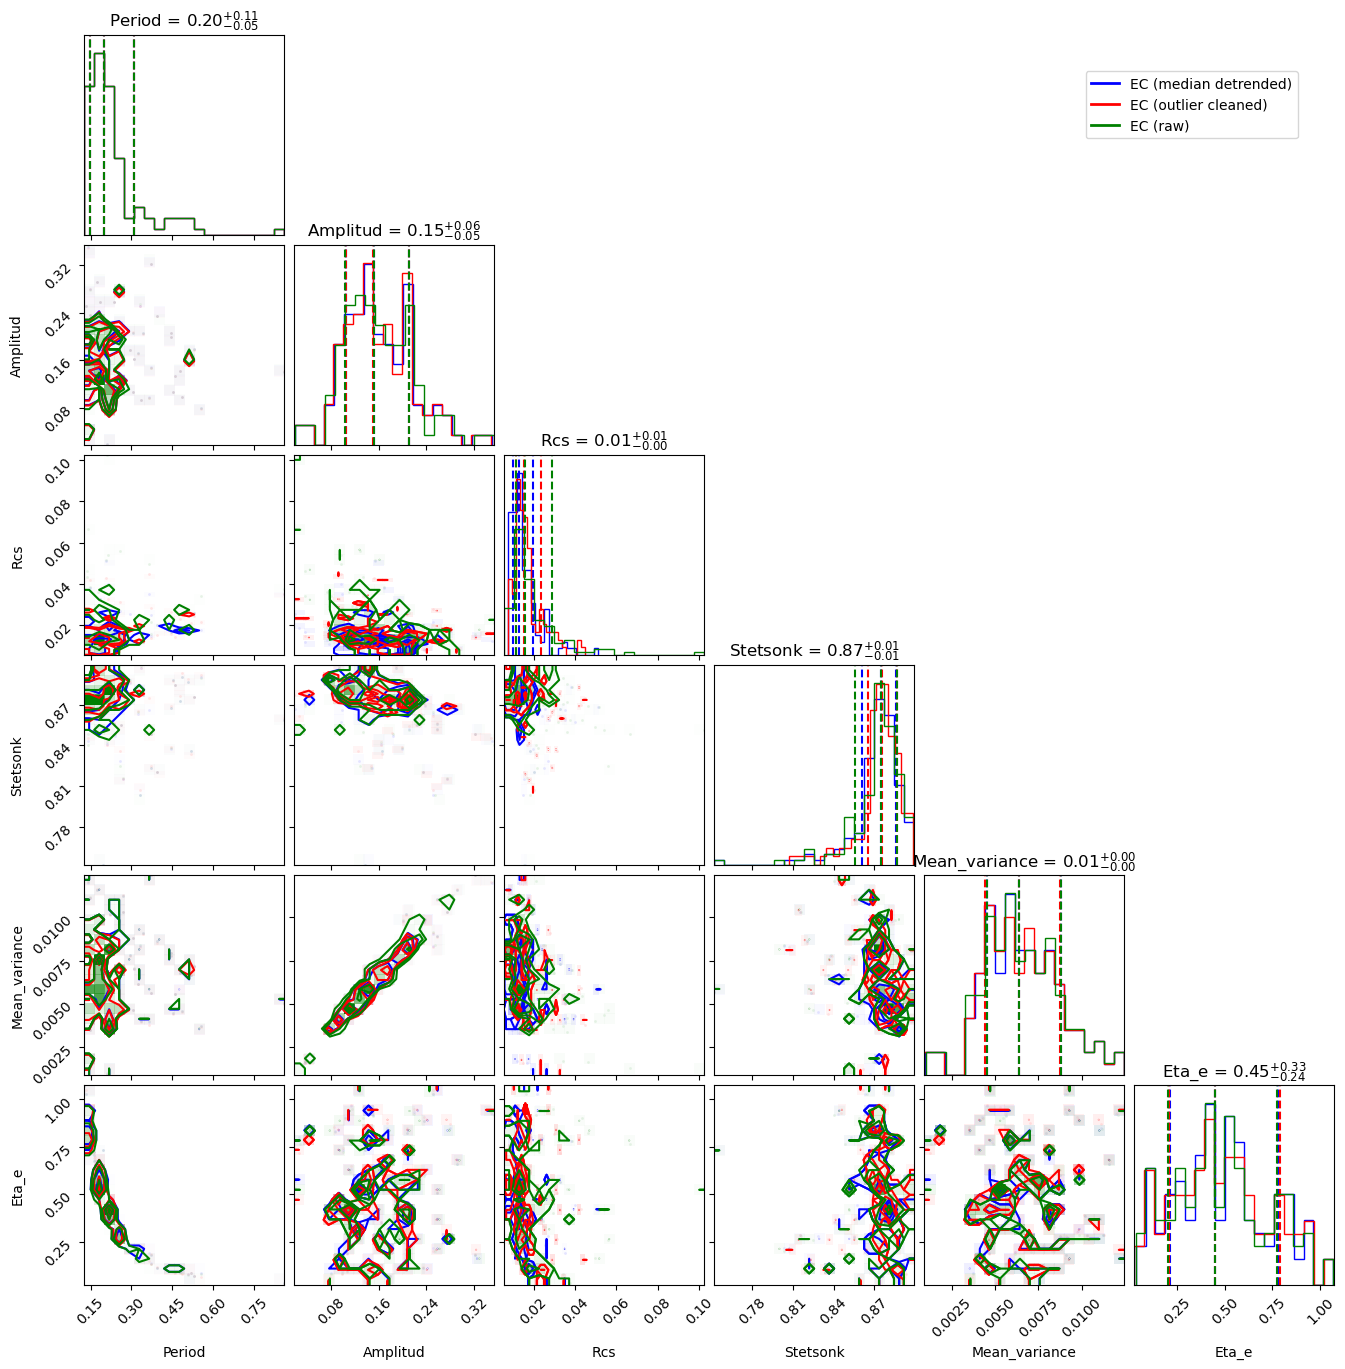

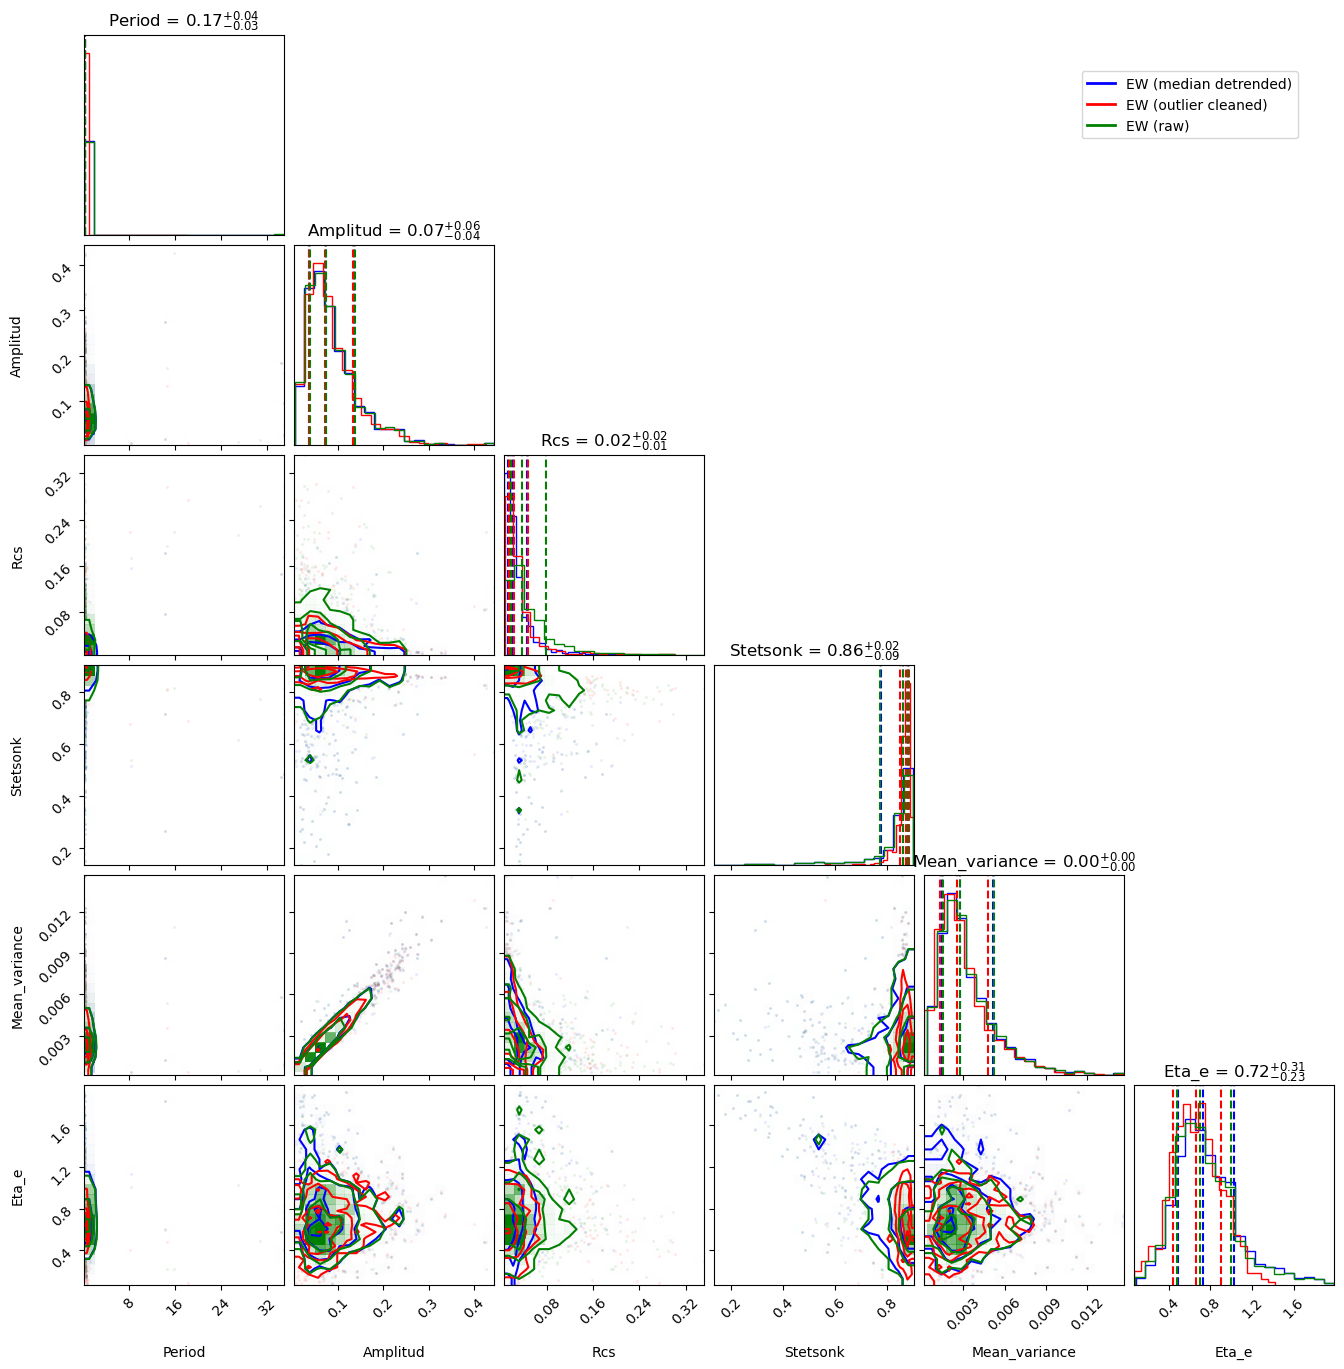

In [9]:
#nueva_lista = ['ROT', 'RS', 'RRD', 'HADS', 'EC', 'EW']

for tipo in tipos_unicos:
    rot_median_after_detrended = df_median_after_detrended[df_median_after_detrended['type'] == tipo]
    rot_raw = df_raw[df_raw["type"]==tipo]
    rot_outlier = df_outlier_cleaned[df_outlier_cleaned["type"]== tipo]
    #lcheking the data leng

    len(rot_median_after_detrended) #== len(rot_outlier) == len(rot_raw)
    features_list = [
    'Period',
    #'FAP',
    'Amplitud',
    'Rcs',
    'Stetsonk',
    'Mean_variance',
    #'Autocor_length',
    #'Con',
    'Eta_e'
    # 'Mean',
    # 'Q31',
    # 'AndersonDarling',
    # 'Gskew',
    # 'StructureFunction_index_21',
    # 'StructureFunction_index_31',
    # 'StructureFunction_index_32',
    # 'Pvar',
    # 'ExcessVar'
]
# we verify if the comun exist 
    for col in features_list:
        if col not in rot_median_after_detrended.columns:
            raise KeyError(f"column '{col}' does not exist in media after detrender.")
        elif col not in rot_outlier.columns:
            raise KeyError(f"column '{col}' does not exist in outlier.")
        elif col not in rot_raw.columns:
            raise KeyError(f"column '{col}' does not exist in raw.")
    data_rot_median = rot_median_after_detrended[features_list].values
    data_rot_outlier = rot_outlier[features_list].values
    data_rot_raw = rot_raw[features_list].values
##creating triangle plots
    
    fig = corner.corner(data_rot_median, labels=features_list,
                        quantiles=[0.16, 0.5, 0.84],
                        show_titles=True,
                        title_kwargs={"fontsize": 12},
                        color='blue',
                        hist_kwargs={'density': True},
                        label=f'{tipo} (median detrended)')
    
    corner.corner(data_rot_outlier, labels=features_list,
                  quantiles=[0.16, 0.5, 0.84],
                  show_titles=False,
                  title_kwargs={"fontsize": 12},
                  color='red',
                  hist_kwargs={'density': True},
                  label=f'{tipo} (outlier cleaned)',
                  fig=fig)
    
    corner.corner(data_rot_raw, labels=features_list,
                  quantiles=[0.16, 0.5, 0.84],
                  show_titles=False,
                  title_kwargs={"fontsize": 12},
                  color='green',
                  hist_kwargs={'density': True},
                  label=f'{tipo} (raw)',
                  fig=fig)
    
    # Leyenda (corner no la añade automáticamente)
    from matplotlib.lines import Line2D
    handles = [Line2D([0], [0], color='blue', lw=2, label=f'{tipo} (median detrended)'),
               Line2D([0], [0], color='red', lw=2, label=f'{tipo} (outlier cleaned)'),
               Line2D([0], [0], color='green', lw=2, label=f'{tipo} (raw)')]
    fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.95, 0.95), fontsize=10)
    
    plt.savefig(f"corner_{tipo.lower()}_comparison.pdf", dpi=300, bbox_inches='tight')
    plt.show()